# Real Estate Investment Advisor

This project aims to develop a machine learning application to assist potential investors in making real estate decisions.

The outcome of the project is to:
* Classify whether a property is a "Good Investment".
* Predict the estimated property price after 5 years.

This notebook shows: 
1. Data Cleaning & Preprcessing 
2. Exploratory Data Analysis & Data Visualization 
3. Feature Engineering 
4. Machine Learning Model Development 
5. Model deployment in Streamlit Web Application


## Importing libraries, datasets and defining utility functions

In [536]:
import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow

In [537]:
# Utility Functions

# Percentage of Missing Values
def per_miss_val(df):
  return 100 * df.isnull().sum() / len(df)

In [538]:
# Read Dataset
df = pd.read_csv('Datasets/india_housing_prices.csv')

# Data Cleaning and Preprocessing for EDA

In [539]:
# First 5 rows
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [540]:
# Last 5 Rows
df.tail()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
249995,249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,274.75,0.14,1995,...,30,8,6,Low,No,No,"Playground, Garden, Gym, Clubhouse, Pool",East,Broker,Under_Construction
249996,249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,13.40,0.01,2013,...,12,8,10,Low,No,No,Playground,South,Broker,Ready_to_Move
249997,249998,Telangana,Warangal,Locality_225,Villa,4,2910,236.94,0.08,2003,...,22,10,4,High,Yes,Yes,Playground,South,Builder,Under_Construction
249998,249999,Odisha,Cuttack,Locality_138,Villa,1,1149,141.66,0.12,2007,...,18,3,7,Low,Yes,Yes,"Playground, Gym, Pool",South,Owner,Ready_to_Move
249999,250000,Haryana,Gurgaon,Locality_268,Independent House,3,4313,199.69,0.05,1990,...,35,10,6,Medium,No,No,"Gym, Garden",South,Owner,Under_Construction


In [541]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [542]:
# Checking for missing/null values in the dataframe
per = per_miss_val(df)

print(f'Percentage of missing values present: \n{per}')

Percentage of missing values present: 
ID                                0.0
State                             0.0
City                              0.0
Locality                          0.0
Property_Type                     0.0
BHK                               0.0
Size_in_SqFt                      0.0
Price_in_Lakhs                    0.0
Price_per_SqFt                    0.0
Year_Built                        0.0
Furnished_Status                  0.0
Floor_No                          0.0
Total_Floors                      0.0
Age_of_Property                   0.0
Nearby_Schools                    0.0
Nearby_Hospitals                  0.0
Public_Transport_Accessibility    0.0
Parking_Space                     0.0
Security                          0.0
Amenities                         0.0
Facing                            0.0
Owner_Type                        0.0
Availability_Status               0.0
dtype: float64


No `null` values identified in the data.

### Property Location Columns

In [543]:
# State Column
print("Property State Stats")
print(df['State'].describe())
print('')
# States Present in the dataset
print(f"States List: {df['State'].unique()}")

Property State Stats
count     250000
unique        20
top       Odisha
freq       12681
Name: State, dtype: object

States List: ['Tamil Nadu' 'Maharashtra' 'Punjab' 'Rajasthan' 'West Bengal'
 'Chhattisgarh' 'Delhi' 'Jharkhand' 'Telangana' 'Karnataka'
 'Uttar Pradesh' 'Assam' 'Uttarakhand' 'Bihar' 'Gujarat' 'Haryana'
 'Andhra Pradesh' 'Madhya Pradesh' 'Kerala' 'Odisha']


In [544]:
# Checking for datatype consistency
dtypes = list(df['State'].apply(type).unique())
print(f"Datatypes present in State column: {dtypes}")

Datatypes present in State column: [<class 'str'>]


In [545]:
# City Column
print("Property City Stats")
print(df['City'].describe())
print('')
# Cities Present in the dataset
print(f"City List: {df['City'].unique()}")

Property City Stats


count         250000
unique            42
top       Coimbatore
freq            6461
Name: City, dtype: object

City List: ['Chennai' 'Pune' 'Ludhiana' 'Jodhpur' 'Jaipur' 'Durgapur' 'Coimbatore'
 'Bilaspur' 'New Delhi' 'Ranchi' 'Warangal' 'Bangalore' 'Nagpur' 'Lucknow'
 'Silchar' 'Dehradun' 'Noida' 'Gaya' 'Jamshedpur' 'Ahmedabad' 'Hyderabad'
 'Faridabad' 'Amritsar' 'Kolkata' 'Dwarka' 'Vishakhapatnam' 'Bhopal'
 'Indore' 'Haridwar' 'Mysore' 'Patna' 'Raipur' 'Vijayawada' 'Trivandrum'
 'Kochi' 'Surat' 'Gurgaon' 'Mangalore' 'Cuttack' 'Bhubaneswar' 'Guwahati'
 'Mumbai']


In [546]:
# Locality Column
print('Property Locality Stats')
print(df['Locality'].describe())
print('')
# List of localities
print("Locality List")
df['Locality'].unique()

Property Locality Stats
count           250000
unique             500
top       Locality_296
freq               567
Name: Locality, dtype: object

Locality List


array(['Locality_84', 'Locality_490', 'Locality_167', 'Locality_393',
       'Locality_466', 'Locality_246', 'Locality_254', 'Locality_232',
       'Locality_122', 'Locality_75', 'Locality_462', 'Locality_227',
       'Locality_287', 'Locality_148', 'Locality_369', 'Locality_265',
       'Locality_50', 'Locality_385', 'Locality_241', 'Locality_286',
       'Locality_74', 'Locality_459', 'Locality_355', 'Locality_151',
       'Locality_159', 'Locality_382', 'Locality_143', 'Locality_454',
       'Locality_262', 'Locality_136', 'Locality_223', 'Locality_368',
       'Locality_480', 'Locality_485', 'Locality_398', 'Locality_305',
       'Locality_114', 'Locality_202', 'Locality_96', 'Locality_295',
       'Locality_58', 'Locality_484', 'Locality_323', 'Locality_432',
       'Locality_273', 'Locality_458', 'Locality_150', 'Locality_238',
       'Locality_494', 'Locality_464', 'Locality_431', 'Locality_125',
       'Locality_218', 'Locality_112', 'Locality_27', 'Locality_40',
       'Locali

In [547]:
# Replacing Locality data with locality number only
"""def extract_locality_number(val):
  val_list = val.split("_")
  return str(val_list[1])

df['Locality'] = df['Locality'].apply(lambda x: extract_locality_number(x))
df['Locality']"""

'def extract_locality_number(val):\n  val_list = val.split("_")\n  return str(val_list[1])\n\ndf[\'Locality\'] = df[\'Locality\'].apply(lambda x: extract_locality_number(x))\ndf[\'Locality\']'

In [548]:
# Stats about property location
print("Property Location Stats")
df[['State','City','Locality']].describe(include='all')

Property Location Stats


,State,City,Locality
count,250000,250000,250000
unique,20,42,500
top,Odisha,Coimbatore,Locality_296
freq,12681,6461,567


### Property Specifications, Age and Amenities Columns

In [549]:
# Property Type column
print("Property Type Stats")
print(df['Property_Type'].describe())
print('')
# List of Property Types
print("Property Types: ", df['Property_Type'].unique())

Property Type Stats
count     250000
unique         3
top        Villa
freq       83744
Name: Property_Type, dtype: object

Property Types:  ['Apartment' 'Independent House' 'Villa']


In [550]:
# Stats about BHK
print("Property BHK stats")
print(df['BHK'].describe())
print('')
print(f"BHK Types: {df['BHK'].unique()}")

Property BHK stats
count    250000.000000
mean          2.999396
std           1.415521
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: BHK, dtype: float64

BHK Types: [1 3 2 4 5]


In [551]:
# Stats about Sqft
print("Property Size(In Sqft) Stats")
df['Size_in_SqFt'].describe()

Property Size(In Sqft) Stats


count    250000.000000
mean       2749.813216
std        1300.606954
min         500.000000
25%        1623.000000
50%        2747.000000
75%        3874.000000
max        5000.000000
Name: Size_in_SqFt, dtype: float64

In [552]:
# Stats about Price
print("Property Price(In Lakhs) Stats")
df['Price_in_Lakhs'].describe()

Property Price(In Lakhs) Stats


count    250000.000000
mean        254.586854
std         141.349921
min          10.000000
25%         132.550000
50%         253.870000
75%         376.880000
max         500.000000
Name: Price_in_Lakhs, dtype: float64

In [553]:
# Stats about Price per Sqft
print("Price Per SqFt(In Lakhs) Stats")
df['Price_per_SqFt'].describe()

Price Per SqFt(In Lakhs) Stats


count    250000.000000
mean          0.130597
std           0.130747
min           0.000000
25%           0.050000
50%           0.090000
75%           0.160000
max           0.990000
Name: Price_per_SqFt, dtype: float64

Price per sqft cannot be `0` (as shown in the min value).

In [554]:
# No of rows with Price_Per_SqFt = 0
print(f"No of rows with 0: {len(df[df['Price_per_SqFt'] == 0])}")

No of rows with 0: 2534


Let's calculate the `price_per_sqft` using `Price_In_Lakhs` and `Size_in_SqFt`.

In [555]:
# Price_Per_SqFt given in the dataset
existing_price_df = df['Price_per_SqFt']

# Calculate Price_Per_SqFt using Size_in_SqFt and Price_in_Lakhs
calculated_price_round_to_2 = ((df['Price_in_Lakhs']) * 100000 / (df['Size_in_SqFt']) / 100000).round(2)

Let's check if the given price and the calculated price are equal.

In [556]:
# Checking if the existing data and the calculated data are equal to each other
print((calculated_price_round_to_2 == existing_price_df).all())

False


In [557]:
# Rows that mismatch with the given price and the calculated price
mismatch = calculated_price_round_to_2 != existing_price_df
result = pd.DataFrame({
    'calculated': calculated_price_round_to_2[mismatch],
    'existing': existing_price_df[mismatch]
})
result

,calculated,existing
16607,0.52,0.53
26681,0.52,0.53
30731,0.08,0.07
52600,0.16,0.15
68796,0.14,0.15
74153,0.46,0.45
75443,0.08,0.09
75873,0.02,0.01
85357,0.30,0.29
88087,0.00,0.01


In [558]:
# Calculated Price_Per_Sqft Stats
calculated_price_round_to_2.describe()

count    250000.000000
mean          0.130597
std           0.130747
min           0.000000
25%           0.050000
50%           0.090000
75%           0.160000
max           0.990000
dtype: float64

The resulting `0` is an artifact of rounding.

Let's try rounding the value to 3

In [559]:
calculated_price_round_to_3 = ((df['Price_in_Lakhs']) * 100000 / (df['Size_in_SqFt']) / 100000).round(3)

print("Price Per SqFt Rounded to 3 decimal")
calculated_price_round_to_3.describe()

Price Per SqFt Rounded to 3 decimal


count    250000.000000
mean          0.130583
std           0.130719
min           0.002000
25%           0.048000
50%           0.092000
75%           0.160000
max           0.992000
dtype: float64

Let's Check for `0` value rows

In [560]:
print(f"No of rows with 0: {len(calculated_price_round_to_3[calculated_price_round_to_3 == 0])}")

No of rows with 0: 0


Replacing the existing `Price_per_SqFt` with `calculated_price_round_to_3` values, rounded to 3.

In [561]:
df['Price_per_SqFt'] = calculated_price_round_to_3
df['Price_per_SqFt']

0         0.103
1         0.083
2         0.050
3         0.110
4         0.038
          ...  
249995    0.138
249996    0.006
249997    0.081
249998    0.123
249999    0.046
Name: Price_per_SqFt, Length: 250000, dtype: float64

In [562]:
# Year Built Stats
print("Property year built stats")
print(df['Year_Built'].describe())

Property year built stats
count    250000.000000
mean       2006.520012
std           9.808575
min        1990.000000
25%        1998.000000
50%        2007.000000
75%        2015.000000
max        2023.000000
Name: Year_Built, dtype: float64


In [563]:
# Furnish Status Stats
print("Property Furnish Status Stats")
print(df['Furnished_Status'].describe())

print("")
print(f"Furnishing Status: {df['Furnished_Status'].unique()}")

Property Furnish Status Stats
count          250000
unique              3
top       Unfurnished
freq            83408
Name: Furnished_Status, dtype: object

Furnishing Status: ['Furnished' 'Unfurnished' 'Semi-furnished']


In [564]:
# Floor Number Stats
print("Property Floor Number Stats")
print(df['Floor_No'].describe())

Property Floor Number Stats
count    250000.000000
mean         14.966800
std           8.948047
min           0.000000
25%           7.000000
50%          15.000000
75%          23.000000
max          30.000000
Name: Floor_No, dtype: float64


In [565]:
# Total Floors Stats
print("Property Total Floors Stats")
print(df['Total_Floors'].describe())

Property Total Floors Stats
count    250000.000000
mean         15.503004
std           8.671618
min           1.000000
25%           8.000000
50%          15.000000
75%          23.000000
max          30.000000
Name: Total_Floors, dtype: float64


In [566]:
# Age of Property Stats
print("Property Age Stats")
print(df['Age_of_Property'].describe())

Property Age Stats
count    250000.000000
mean         18.479988
std           9.808575
min           2.000000
25%          10.000000
50%          18.000000
75%          27.000000
max          35.000000
Name: Age_of_Property, dtype: float64


In [567]:
# Nearby Schools Stats
print('Schools Nearby the Property Stats')
df['Nearby_Schools'].describe()

Schools Nearby the Property Stats


count    250000.000000
mean          5.499860
std           2.878639
min           1.000000
25%           3.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: Nearby_Schools, dtype: float64

In [568]:
# Nearby Hospitals Stats
print("Hospitals Nearby the Property Stats")
df['Nearby_Hospitals'].describe()

Hospitals Nearby the Property Stats


count    250000.000000
mean          5.498016
std           2.871860
min           1.000000
25%           3.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: Nearby_Hospitals, dtype: float64

In [569]:
# Public Transport Availability Stats
print("Public Transport Availability Stats")
print(df['Public_Transport_Accessibility'].describe())
print("")
print(f'Availability Values : {df['Public_Transport_Accessibility'].unique()}')

Public Transport Availability Stats
count     250000
unique         3
top         High
freq       83705
Name: Public_Transport_Accessibility, dtype: object

Availability Values : ['High' 'Low' 'Medium']


In [570]:
# Parking Space Stats
print("Parking Space Stats")
print(df['Parking_Space'].describe())
print("")
print(f'Values: {df['Parking_Space'].unique()}')

Parking Space Stats
count     250000
unique         2
top           No
freq      125456
Name: Parking_Space, dtype: object

Values: ['No' 'Yes']


In [571]:
# Property Security Stats
print('Property Security Stats')
print(df['Security'].describe())
print("")

print(f'Values: {df['Security'].unique()}')

Property Security Stats
count     250000
unique         2
top          Yes
freq      125233
Name: Security, dtype: object

Values: ['No' 'Yes']


In [572]:
# Amenities Stats
print('Property Amenities Stats')
print(df['Amenities'].describe())

Property Amenities Stats
count     250000
unique       325
top         Pool
freq       10218
Name: Amenities, dtype: object


In [573]:
# Reading the Amenities Column
df['Amenities']

0         Playground, Gym, Garden, Pool, Clubhouse
1         Playground, Clubhouse, Pool, Gym, Garden
2                 Clubhouse, Pool, Playground, Gym
3         Playground, Clubhouse, Gym, Pool, Garden
4         Playground, Garden, Gym, Pool, Clubhouse
                            ...                   
249995    Playground, Garden, Gym, Clubhouse, Pool
249996                                  Playground
249997                                  Playground
249998                       Playground, Gym, Pool
249999                                 Gym, Garden
Name: Amenities, Length: 250000, dtype: object

`Amenities` column holds multi-label categorical values.

Let's split and encode each amenity into its own column.

In [574]:
# Splitting, encoding each amenity and removing amenities column from dataframe
df_amenities = df['Amenities'].str.get_dummies(sep=', ')
#df_amenities = df_amenities.replace({1: 'Yes', 0: 'No'})
df = pd.concat([df, df_amenities], axis=1)
df = df.drop('Amenities', axis=1)
df

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Parking_Space,Security,Facing,Owner_Type,Availability_Status,Clubhouse,Garden,Gym,Playground,Pool
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.103,1990,...,No,No,West,Owner,Ready_to_Move,1,1,1,1,1
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.083,2008,...,No,Yes,North,Builder,Under_Construction,1,1,1,1,1
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.050,1997,...,Yes,No,South,Broker,Ready_to_Move,1,0,1,1,1
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.110,1991,...,Yes,Yes,North,Builder,Ready_to_Move,1,1,1,1,1
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.038,2002,...,No,Yes,East,Builder,Ready_to_Move,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,274.75,0.138,1995,...,No,No,East,Broker,Under_Construction,1,1,1,1,1
249996,249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,13.40,0.006,2013,...,No,No,South,Broker,Ready_to_Move,0,0,0,1,0
249997,249998,Telangana,Warangal,Locality_225,Villa,4,2910,236.94,0.081,2003,...,Yes,Yes,South,Builder,Under_Construction,0,0,0,1,0
249998,249999,Odisha,Cuttack,Locality_138,Villa,1,1149,141.66,0.123,2007,...,Yes,Yes,South,Owner,Ready_to_Move,0,0,1,1,1


In [575]:
# Facing Stats
print("Property Facing Stats")
print(df['Facing'].describe())
print("")
print(f"Values: {df['Facing'].unique()}")

Property Facing Stats
count     250000
unique         4
top         West
freq       62757
Name: Facing, dtype: object

Values: ['West' 'North' 'South' 'East']


In [576]:
# Owner Type Stats
print("Property Owner Type Stats")
print(df['Owner_Type'].describe())
print("")
print(f"Unique Values: {df['Owner_Type'].unique()}")

Property Owner Type Stats
count     250000
unique         3
top       Broker
freq       83479
Name: Owner_Type, dtype: object

Unique Values: ['Owner' 'Builder' 'Broker']


In [577]:
# Property Availability Stats
print("Property Availability Stats")
print(df['Availability_Status'].describe())
print("")
print(f'Values: {df['Availability_Status'].unique()}')

Property Availability Stats
count                 250000
unique                     2
top       Under_Construction
freq                  125035
Name: Availability_Status, dtype: object

Values: ['Ready_to_Move' 'Under_Construction']


In [578]:
# Replacing availability values with Yes/No
df['Availability_Status'] = df['Availability_Status'].replace({'Ready_to_Move':'Yes', 'Under_Construction': 'No'})
print(f'Property Availability Values : {df['Availability_Status'].unique()}')

Property Availability Values : ['Yes' 'No']


In [579]:
# Renaming Columns
df.rename(columns={'Nearby_Schools':'Total_Nearby_Schools', 'Nearby_Hospitals': 'Total_Nearby_Hospitals', 'Price_per_SqFt': 'Price_per_SqFt_in_Lakhs', 'Facing':'Direction_Facing'}, inplace=True)
df

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt_in_Lakhs,Year_Built,...,Parking_Space,Security,Direction_Facing,Owner_Type,Availability_Status,Clubhouse,Garden,Gym,Playground,Pool
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.103,1990,...,No,No,West,Owner,Yes,1,1,1,1,1
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.083,2008,...,No,Yes,North,Builder,No,1,1,1,1,1
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.050,1997,...,Yes,No,South,Broker,Yes,1,0,1,1,1
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.110,1991,...,Yes,Yes,North,Builder,Yes,1,1,1,1,1
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.038,2002,...,No,Yes,East,Builder,Yes,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,274.75,0.138,1995,...,No,No,East,Broker,No,1,1,1,1,1
249996,249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,13.40,0.006,2013,...,No,No,South,Broker,Yes,0,0,0,1,0
249997,249998,Telangana,Warangal,Locality_225,Villa,4,2910,236.94,0.081,2003,...,Yes,Yes,South,Builder,No,0,0,0,1,0
249998,249999,Odisha,Cuttack,Locality_138,Villa,1,1149,141.66,0.123,2007,...,Yes,Yes,South,Owner,Yes,0,0,1,1,1


In [580]:
# Rearranging columns for better associations
df = df[['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_per_SqFt_in_Lakhs', 'Price_in_Lakhs', 'Year_Built', 'Furnished_Status', 'Direction_Facing', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Owner_Type', 'Availability_Status', 'Total_Nearby_Schools', 'Total_Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Clubhouse', 'Garden', 'Gym', 'Playground', 'Pool']]
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,...,Total_Nearby_Schools,Total_Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Clubhouse,Garden,Gym,Playground,Pool
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,0.103,489.76,1990,...,10,3,High,No,No,1,1,1,1,1
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,0.083,195.52,2008,...,8,1,Low,No,Yes,1,1,1,1,1
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,0.050,183.79,1997,...,9,8,Low,Yes,No,1,0,1,1,1
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,0.110,300.29,1991,...,5,7,High,Yes,Yes,1,1,1,1,1
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,0.038,182.90,2002,...,4,9,Low,No,Yes,1,1,1,1,1


In [581]:
# Final Dataset information for EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_per_SqFt_in_Lakhs         250000 non-null  float64
 8   Price_in_Lakhs                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Direction_Facing                250000 non-null  object 
 12  Floor_No        

In [582]:
# Final Stats
df.describe(include='all')

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,...,Total_Nearby_Schools,Total_Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Clubhouse,Garden,Gym,Playground,Pool
count,250000.000000,250000,250000,250000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000,250000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
unique,NaN,20,42,500,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3,2,2,NaN,NaN,NaN,NaN,NaN
top,NaN,Odisha,Coimbatore,Locality_296,Villa,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,High,No,Yes,NaN,NaN,NaN,NaN,NaN
freq,NaN,12681,6461,567,83744,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83705,125456,125233,NaN,NaN,NaN,NaN,NaN
mean,125000.500000,NaN,NaN,NaN,NaN,2.999396,2749.813216,0.130583,254.586854,2006.520012,...,5.499860,5.498016,NaN,NaN,NaN,0.600236,0.600708,0.599840,0.599120,0.600384
std,72168.927986,NaN,NaN,NaN,NaN,1.415521,1300.606954,0.130719,141.349921,9.808575,...,2.878639,2.871860,NaN,NaN,NaN,0.489851,0.489754,0.489932,0.490078,0.489820
min,1.000000,NaN,NaN,NaN,NaN,1.000000,500.000000,0.002000,10.000000,1990.000000,...,1.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,62500.750000,NaN,NaN,NaN,NaN,2.000000,1623.000000,0.048000,132.550000,1998.000000,...,3.000000,3.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
50%,125000.500000,NaN,NaN,NaN,NaN,3.000000,2747.000000,0.092000,253.870000,2007.000000,...,5.000000,5.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000
75%,187500.250000,NaN,NaN,NaN,NaN,4.000000,3874.000000,0.160000,376.880000,2015.000000,...,8.000000,8.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000


# **Exploratory Data Analysis**

## 1. Price and Size Analysis (1-5)

### 1.1 Property Price Distribution

In [583]:
df['Price_in_Lakhs'].describe()

count    250000.000000
mean        254.586854
std         141.349921
min          10.000000
25%         132.550000
50%         253.870000
75%         376.880000
max         500.000000
Name: Price_in_Lakhs, dtype: float64

In [584]:
# Creating price buckets
bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, np.inf]
labels = ['0 to 50L', '50L to 1Cr', '1Cr to 1.5Cr', '1.5Cr to 2Cr', '2Cr to 2.5 Cr', '2.5Cr to 3Cr', '3Cr to 3.5Cr', '3.5Cr to 4Cr', '4Cr to 4.5 Cr', '4.5Cr to 5Cr', '5Cr and more']
price_bucket = pd.cut(df['Price_in_Lakhs'], bins=bins, labels=labels) # (left, right]
price_bucket_counts = price_bucket.value_counts().sort_index()
print("Property Price Distribution")
price_bucket_counts

Property Price Distribution


Price_in_Lakhs
0 to 50L         20307
50L to 1Cr       25432
1Cr to 1.5Cr     25824
1.5Cr to 2Cr     25954
2Cr to 2.5 Cr    25604
2.5Cr to 3Cr     25260
3Cr to 3.5Cr     25502
3.5Cr to 4Cr     25252
4Cr to 4.5 Cr    25263
4.5Cr to 5Cr     25602
5Cr and more         0
Name: count, dtype: int64

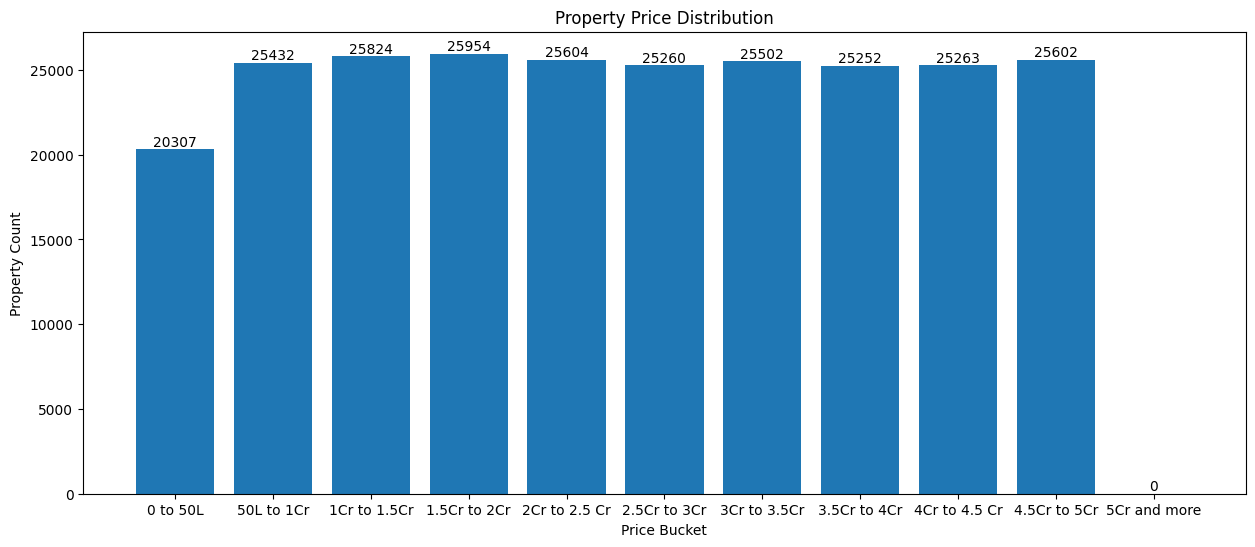

In [585]:
# Visualization
plt.figure(figsize=(15,6))
plt.bar(price_bucket_counts.index, price_bucket_counts.values)

for index, value in zip(price_bucket_counts.index, price_bucket_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title("Property Price Distribution")
plt.xlabel("Price Bucket")
plt.ylabel("Property Count")
plt.show()

### 1.2 Property Size Distribution

In [586]:
df['Size_in_SqFt'].describe()

count    250000.000000
mean       2749.813216
std        1300.606954
min         500.000000
25%        1623.000000
50%        2747.000000
75%        3874.000000
max        5000.000000
Name: Size_in_SqFt, dtype: float64

In [587]:
# Creating Size bucket
bins = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, np.inf]
labels = ['0 to 500', '500 to 1000', '1000 to 1500', '1500 to 2000', '2000 to 2500', '2500 to 3000', '3000 to 3500', '3500 to 4000', '4000 to 4500', '4500 to 5000', '5000 and above']
size_bucket = pd.cut(df['Size_in_SqFt'], bins=bins, labels=labels)
size_bucket_counts = size_bucket.value_counts().sort_index()
print("Property Size Distribution")
size_bucket_counts

Property Size Distribution


Size_in_SqFt
0 to 500             57
500 to 1000       27940
1000 to 1500      27644
1500 to 2000      27682
2000 to 2500      27838
2500 to 3000      27826
3000 to 3500      27686
3500 to 4000      27766
4000 to 4500      27591
4500 to 5000      27970
5000 and above        0
Name: count, dtype: int64

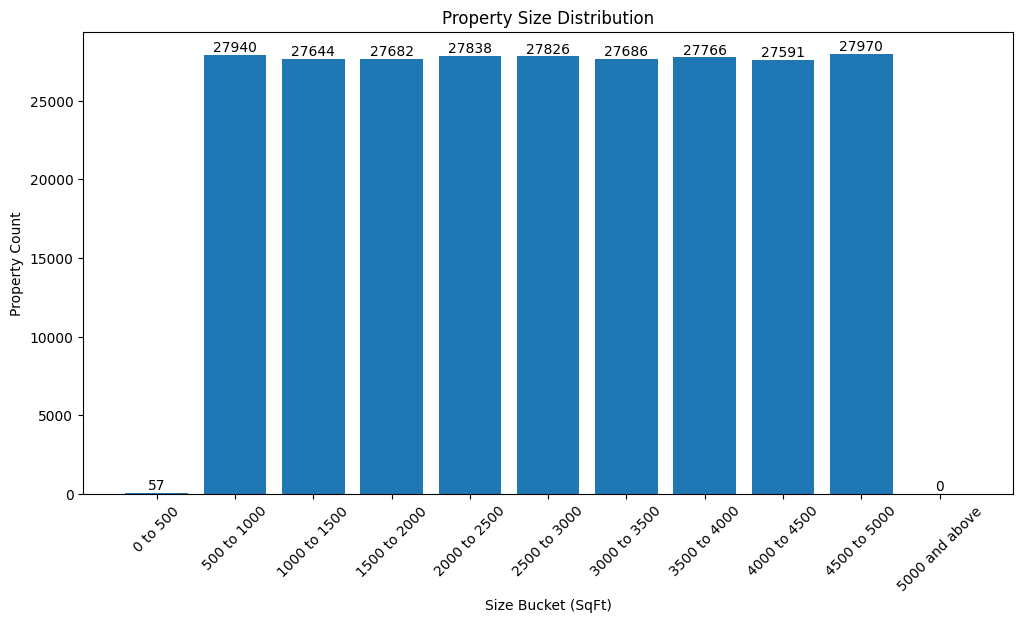

In [588]:
# Visualization
plt.figure(figsize=(12, 6))
plt.bar(size_bucket_counts.index, size_bucket_counts.values)

for index, value in zip(size_bucket_counts.index, size_bucket_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.xticks(rotation=45)
plt.title("Property Size Distribution")
plt.xlabel("Size Bucket (SqFt)")
plt.ylabel("Property Count")
plt.show()

### 1.3 Price per Sqft based on Property Type

In [589]:
df[['Property_Type', 'Price_per_SqFt_in_Lakhs']]

,Property_Type,Price_per_SqFt_in_Lakhs
0,Apartment,0.103
1,Independent House,0.083
2,Apartment,0.050
3,Independent House,0.110
4,Villa,0.038
...,...,...
249995,Independent House,0.138
249996,Apartment,0.006
249997,Villa,0.081
249998,Villa,0.123


In [590]:
# Stats for Price Per SqFt Based on Property Type
price_per_sqft_on_type = (df.groupby('Property_Type')['Price_per_SqFt_in_Lakhs']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .sort_values('mean')
)
price_per_sqft_on_type['mean'] = price_per_sqft_on_type['mean'].round(6) * 100000
price_per_sqft_on_type['median'] = price_per_sqft_on_type['median'].round(6) * 100000
print("Price per Sqft Based on Property Type")
price_per_sqft_on_type

Price per Sqft Based on Property Type


,Property_Type,mean,median,count
2,Villa,13025.7,9200.0,83744
0,Apartment,13047.2,9200.0,82956
1,Independent House,13102.0,9300.0,83300


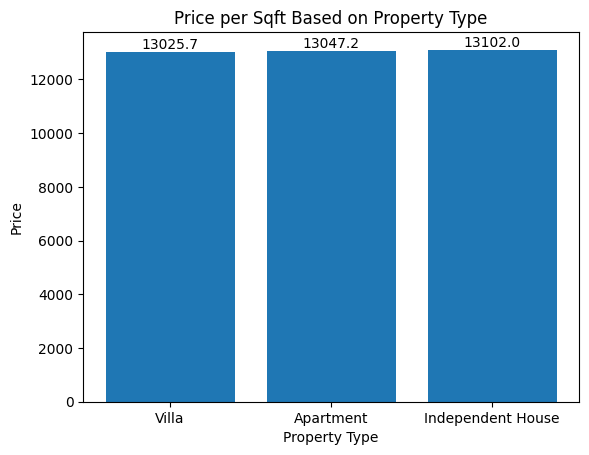

In [591]:
# Visualization
plt.bar(price_per_sqft_on_type['Property_Type'], (price_per_sqft_on_type['mean']))

for index, value in zip(price_per_sqft_on_type['Property_Type'], (price_per_sqft_on_type['mean'])):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title("Price per Sqft Based on Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price")
plt.show()

### 1.4 Relationship between Property Size and Price

In [592]:
size_price_df = df[['Size_in_SqFt', 'Price_in_Lakhs']].copy()
size_price_df

,Size_in_SqFt,Price_in_Lakhs
0,4740,489.76
1,2364,195.52
2,3642,183.79
3,2741,300.29
4,4823,182.90
...,...,...
249995,1995,274.75
249996,2293,13.40
249997,2910,236.94
249998,1149,141.66


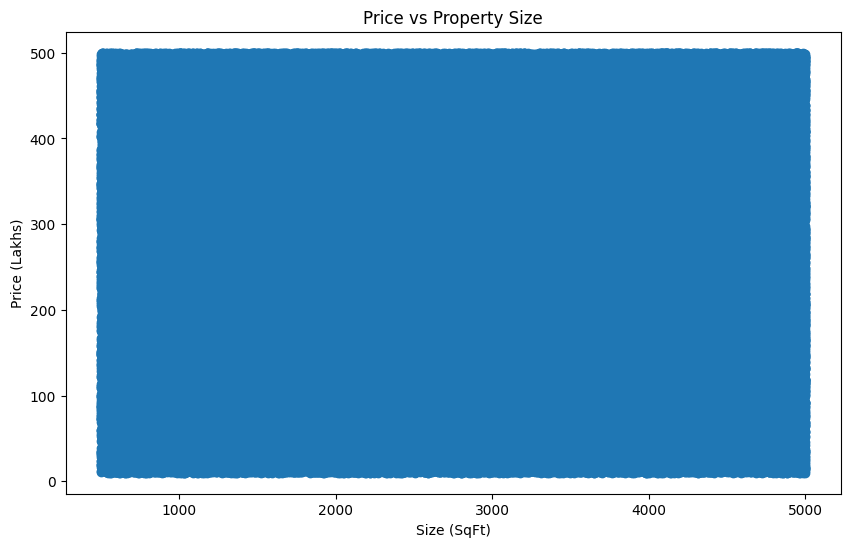

In [593]:
# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(size_price_df['Size_in_SqFt'], size_price_df['Price_in_Lakhs'])

plt.xlabel('Size (SqFt)')
plt.ylabel('Price (Lakhs)')
plt.title('Price vs Property Size')

plt.show()

In [594]:
# Summary Statistics
bins = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, np.inf]
labels = ['0 to 500', '500 to 1000', '1000 to 1500', '1500 to 2000', '2000 to 2500', '2500 to 3000', '3000 to 3500', '3500 to 4000', '4000 to 4500', '4500 to 5000', '5000 and above']
size_price_df['Size_Bucket'] = pd.cut(size_price_df['Size_in_SqFt'], bins=bins, labels=labels)
print("Summary on\nProperty Price(in Lakhs) Based on Size(in SqFt)")
price_based_on_size = size_price_df.groupby('Size_Bucket')['Price_in_Lakhs'].agg(['mean','median','count']).reset_index()
price_based_on_size

Summary on
Property Price(in Lakhs) Based on Size(in SqFt)


,Size_Bucket,mean,median,count
0,0 to 500,260.345088,268.150,57
1,500 to 1000,255.942204,257.540,27940
2,1000 to 1500,255.644476,254.745,27644
3,1500 to 2000,254.229250,253.870,27682
4,2000 to 2500,254.168149,254.165,27838
5,2500 to 3000,253.892024,252.925,27826
6,3000 to 3500,253.650536,251.815,27686
7,3500 to 4000,254.918367,254.265,27766
8,4000 to 4500,254.869355,252.580,27591
9,4500 to 5000,253.956874,252.760,27970


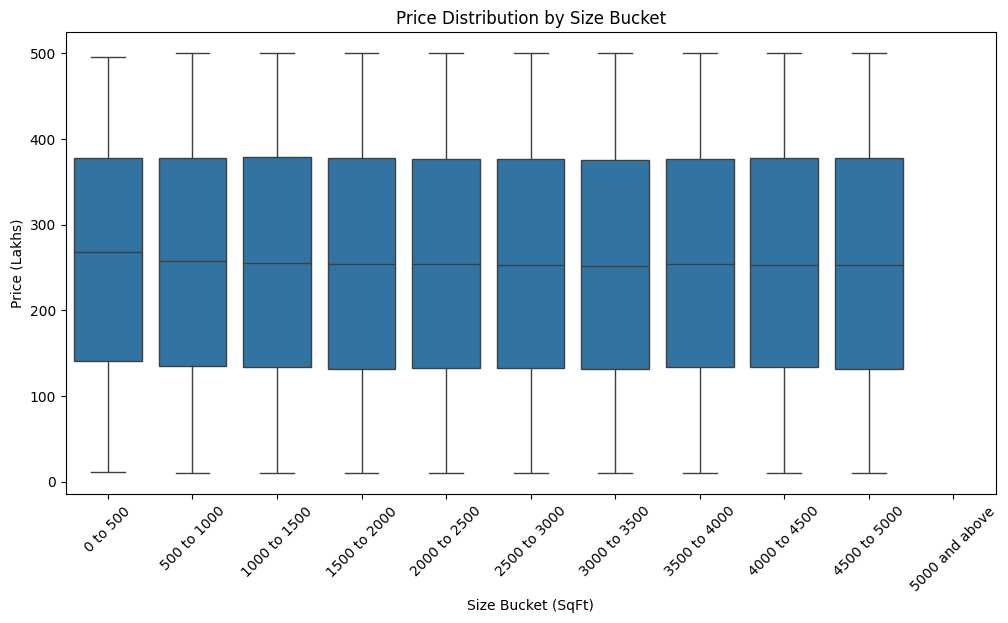

In [595]:
# Visualization of Summary
plt.figure(figsize=(12, 6))
sns.boxplot(data=size_price_df, x='Size_Bucket', y='Price_in_Lakhs')

plt.xticks(rotation=45)
plt.xlabel('Size Bucket (SqFt)')
plt.ylabel('Price (Lakhs)')
plt.title('Price Distribution by Size Bucket')

plt.show()

### 1.5 Outliers in Price per Sqft and Property Size

### For Price per Sqft

In [596]:
df['Price_per_SqFt_in_Lakhs'].describe()

count    250000.000000
mean          0.130583
std           0.130719
min           0.002000
25%           0.048000
50%           0.092000
75%           0.160000
max           0.992000
Name: Price_per_SqFt_in_Lakhs, dtype: float64

The price difference between 75%ile of the properties and the property with the most price per sqft is **too large**. Let's visualize and see how much outliers are present in the dataset.

In [597]:
# IQR
Q1 = df['Price_per_SqFt_in_Lakhs'].quantile(0.25)
Q3 = df['Price_per_SqFt_in_Lakhs'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Price_per_SqFt_in_Lakhs'] < lower_bound) | (df['Price_per_SqFt_in_Lakhs'] > upper_bound)]

print("Inter Quartile Range Calculation")
print(f"Q1 (25%ile): {Q1}")
print(f"Q3 (75%ile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Whisker: {lower_bound}")
print(f"Upper Whisker: {upper_bound}\n")
print(f"Unusual/Rare Price per SqFt (Outliers) Present in the dataset: {outliers.shape[0]} out of {df.shape[0]}")

Inter Quartile Range Calculation
Q1 (25%ile): 0.048
Q3 (75%ile): 0.16
IQR: 0.112
Lower Whisker: -0.12000000000000001
Upper Whisker: 0.328

Unusual/Rare Price per SqFt (Outliers) Present in the dataset: 19621 out of 250000


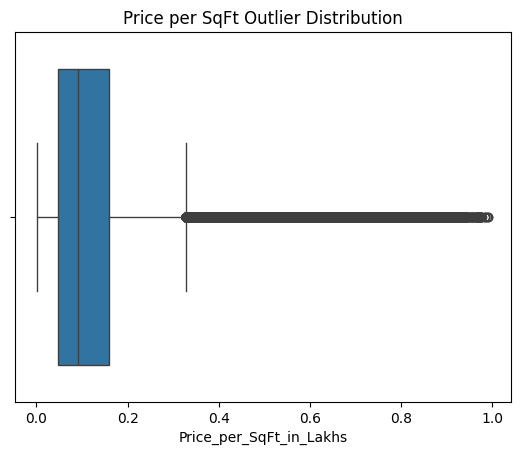

In [598]:
# Outlier Visualization
sns.boxplot(x=df['Price_per_SqFt_in_Lakhs'])
plt.title("Price per SqFt Outlier Distribution")
plt.show()

The right skewed outliers in `Price_per_SqFt_in_Lakhs` are **not** random outliers.

They are small-sized properties behaving exactly as expected.

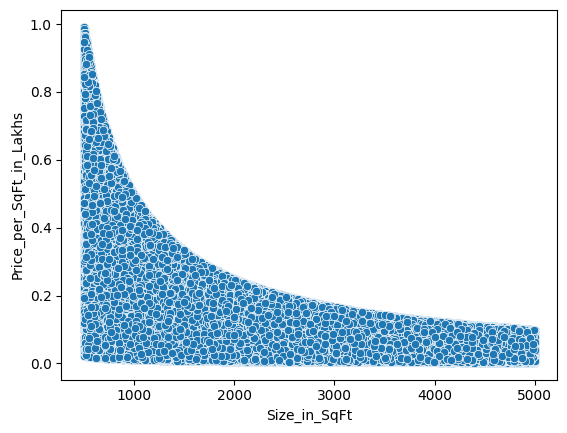

In [599]:
sns.scatterplot(data=df, x='Size_in_SqFt', y='Price_per_SqFt_in_Lakhs')
plt.show()

The scatterplot above shows a non linear relationship between the `price_per_sqft` and `size`.

### For property size

In [600]:
# Summary stats on Property Size
df['Size_in_SqFt'].describe()

count    250000.000000
mean       2749.813216
std        1300.606954
min         500.000000
25%        1623.000000
50%        2747.000000
75%        3874.000000
max        5000.000000
Name: Size_in_SqFt, dtype: float64

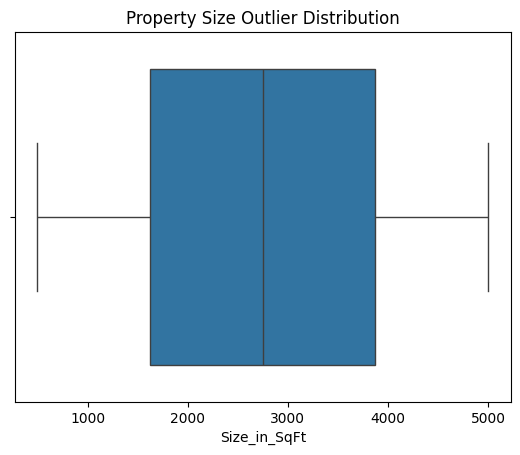

In [601]:
# Visualization
sns.boxplot(data=df, x='Size_in_SqFt')
plt.title("Property Size Outlier Distribution")
plt.show()

There seems to be no unusual/rare (outliers) present in `Property Size`

## 2. Location Based Analysis (6-10)

### 2.1 Average price per SqFt by State

In [602]:
# Calculating average price per sqft by city
price_per_sqft_state_df = (df.groupby('State')['Price_per_SqFt_in_Lakhs']
    .agg(['mean'])
    .rename(columns={'mean':'avg_price_per_sqft'})  
    .reset_index()      
)
price_per_sqft_state_df['avg_price_per_sqft'] = price_per_sqft_state_df['avg_price_per_sqft'] * 100000
print("Average Price per SqFt by City")
price_per_sqft_state_df

Average Price per SqFt by City


,State,avg_price_per_sqft
0,Andhra Pradesh,13201.998074
1,Assam,13084.314981
2,Bihar,13050.578058
3,Chhattisgarh,13027.223828
4,Delhi,12941.244423
5,Gujarat,13091.063762
6,Haryana,13068.450544
7,Jharkhand,12975.400641
8,Karnataka,13252.028332
9,Kerala,12982.293585


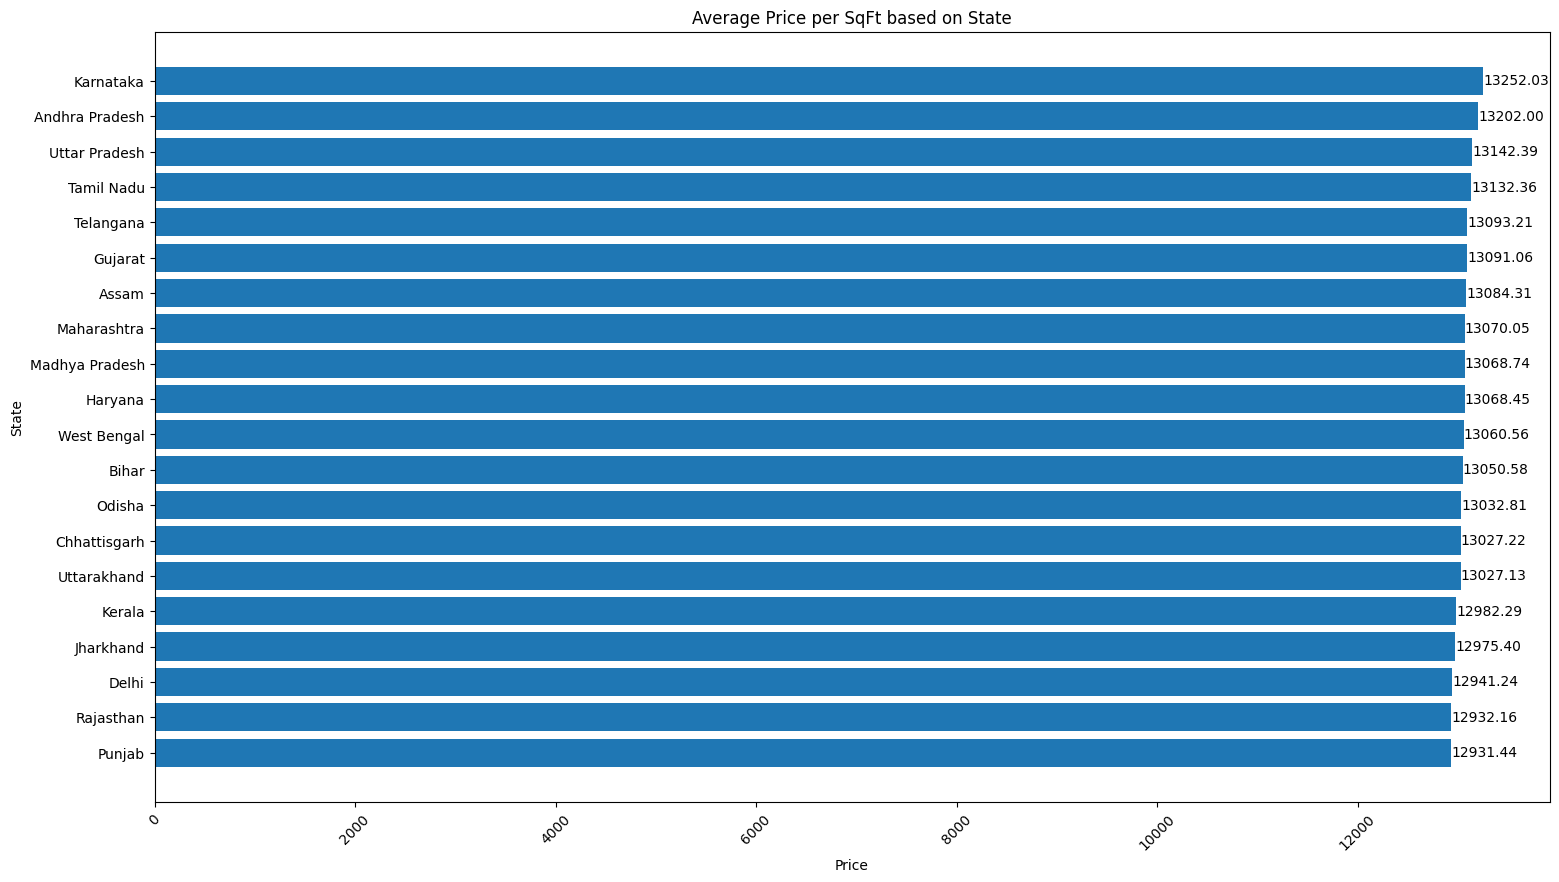

In [603]:
# Visualization
price_per_sqft_state_df.sort_values('avg_price_per_sqft', inplace=True)
plt.figure(figsize=(18,10))
plt.barh(price_per_sqft_state_df['State'], price_per_sqft_state_df['avg_price_per_sqft'])

for index, value in zip(price_per_sqft_state_df['State'], price_per_sqft_state_df['avg_price_per_sqft']):
    plt.text(value, index, f"{value:.2f}", ha='left', va='center')

plt.xticks(rotation=45)
plt.xlabel("Price")
plt.ylabel("State")
plt.title("Average Price per SqFt based on State")
plt.show()

### 2.2 Average property price by city

In [604]:
# Calculating average property price by city
avg_price_by_city_df = (df.groupby('City')['Price_in_Lakhs']
    .agg(['mean'])
    .reset_index()
    .rename(columns={'mean': 'Avg_Price'})
)
print("Average Property Price Based on City")
avg_price_by_city_df

Average Property Price Based on City


,City,Avg_Price
0,Ahmedabad,253.586827
1,Amritsar,252.429802
2,Bangalore,258.456639
3,Bhopal,256.498896
4,Bhubaneswar,254.902173
5,Bilaspur,251.879267
6,Chennai,256.830172
7,Coimbatore,256.504745
8,Cuttack,250.786672
9,Dehradun,256.890115


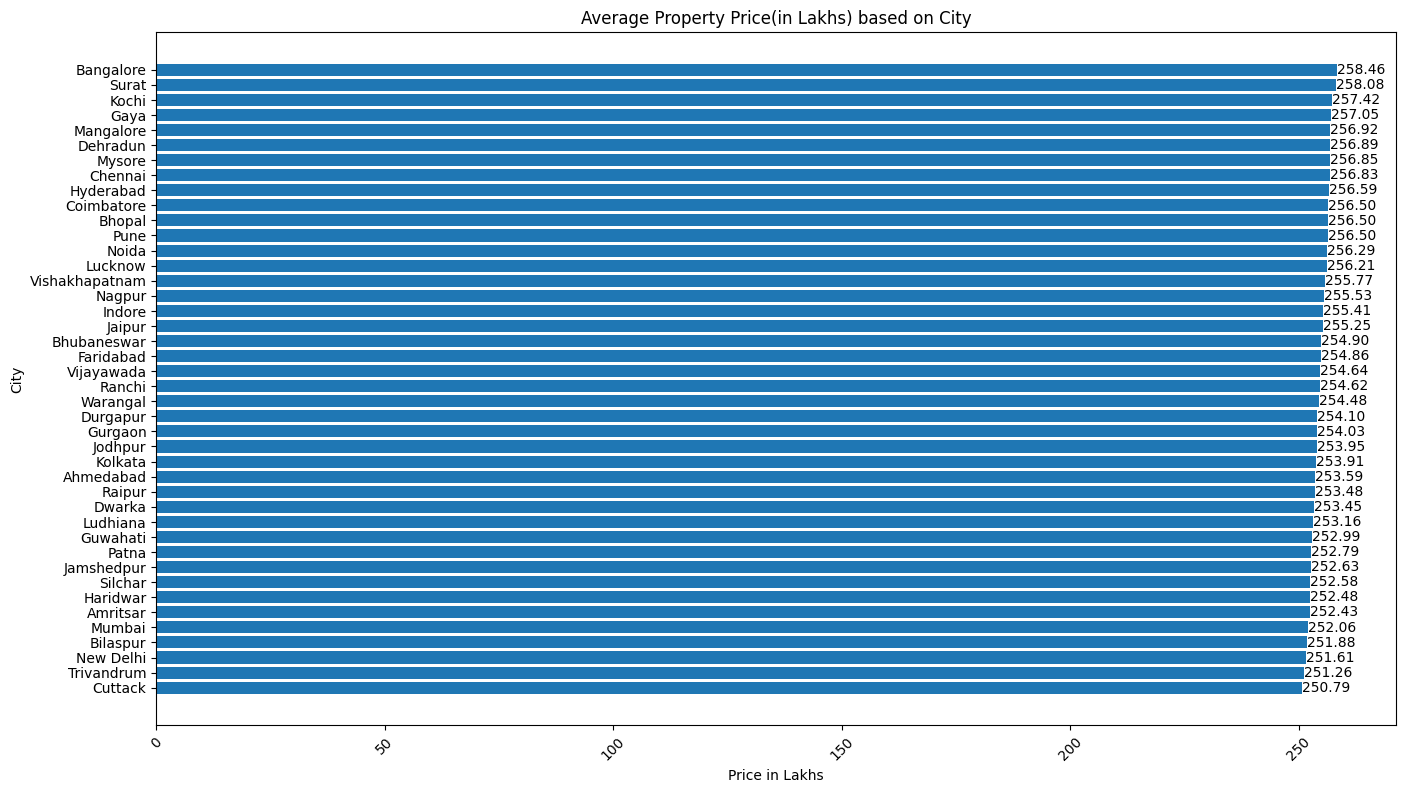

In [605]:
# Visualization
avg_price_by_city_df.sort_values('Avg_Price', inplace=True)
plt.figure(figsize=(16,9))
plt.barh(avg_price_by_city_df['City'], avg_price_by_city_df['Avg_Price'])

for index, value in zip(avg_price_by_city_df['City'], avg_price_by_city_df['Avg_Price']):
    plt.text(value, index, f"{value:.2f}", ha='left', va='center')

plt.xticks(rotation=45)
plt.xlabel("Price in Lakhs")
plt.ylabel("City")
plt.title("Average Property Price(in Lakhs) based on City")
plt.show()

### 2.3 Median Age of Properties by Locality

In [606]:
age_by_locality_df = (df.groupby('Locality')['Age_of_Property']
    .agg(['median'])
    .reset_index()
    .rename(columns={'median': 'median_property_age'})
)
print("Median property age based on locality")
age_by_locality_df

Median property age based on locality


,Locality,median_property_age
0,Locality_1,20.0
1,Locality_10,17.0
2,Locality_100,19.0
3,Locality_101,19.0
4,Locality_102,19.0
...,...,...
495,Locality_95,19.0
496,Locality_96,19.0
497,Locality_97,18.0
498,Locality_98,18.0


In [607]:
# Property Count based on median property age
print("Property count based on median property age")
count_locality = age_by_locality_df.groupby('median_property_age')['Locality'].size()
count_locality

Property count based on median property age


median_property_age
16.0      1
17.0     41
17.5      4
18.0    206
18.5     10
19.0    194
19.5      3
20.0     39
21.0      2
Name: Locality, dtype: int64

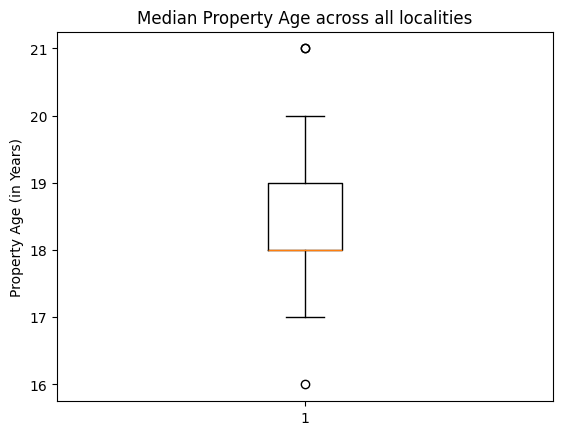

In [608]:
# Visualization
plt.boxplot(age_by_locality_df['median_property_age'])
plt.title('Median Property Age across all localities')
plt.ylabel('Property Age (in Years)')
plt.show()

### 2.4 BHK distribution across Cities

In [609]:
BHK_City_dist = df.groupby(['City', 'BHK']).size().unstack()
BHK_City_dist

BHK,1,2,3,4,5
City,,,,,
Ahmedabad,1264,1267,1272,1258,1350
Amritsar,1284,1239,1234,1224,1240
Bangalore,839,823,802,833,847
Bhopal,1238,1235,1255,1259,1297
Bhubaneswar,1236,1293,1299,1217,1278
Bilaspur,1210,1252,1275,1268,1258
Chennai,1263,1232,1183,1257,1233
Coimbatore,1236,1301,1317,1345,1262
Cuttack,1320,1292,1301,1236,1209


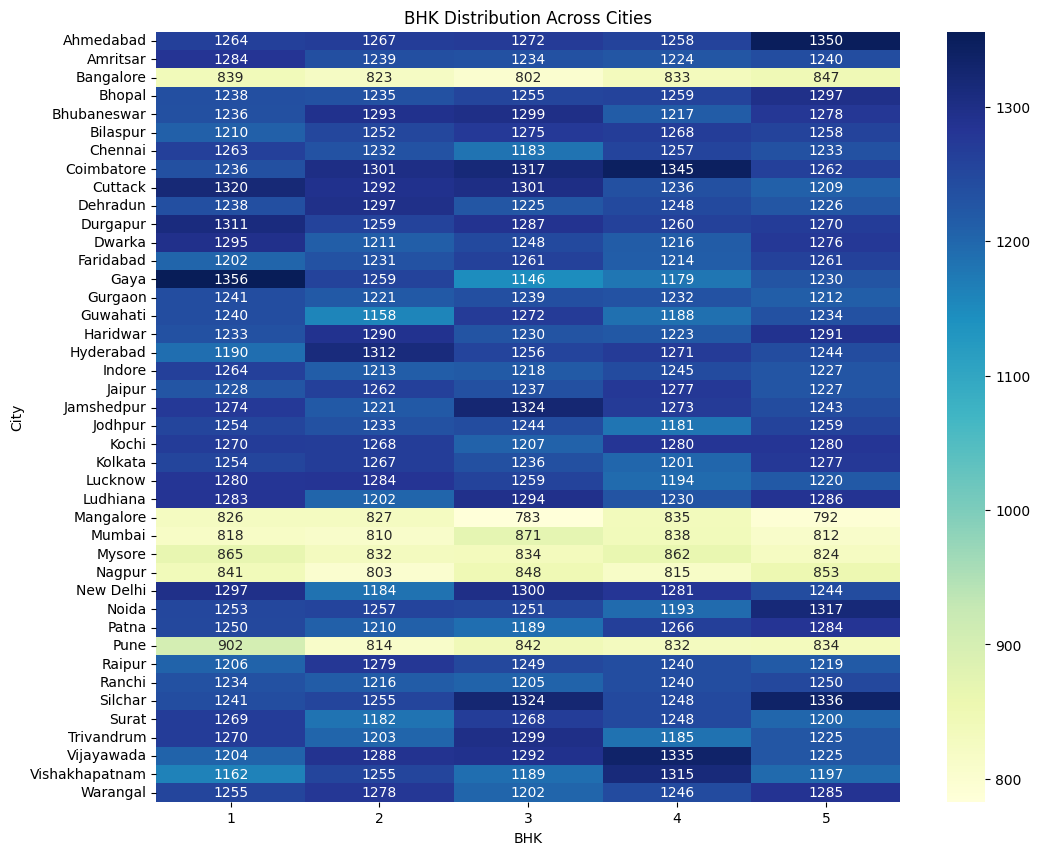

In [610]:
# Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(BHK_City_dist, annot=True, fmt='d', cmap='YlGnBu')
plt.title("BHK Distribution Across Cities")
plt.show()

### 2.5 Price trends for top 5 expensive localities

In [611]:
# Average price based on locality for each city
avg_price = (
  df.groupby(['City', 'Locality'])['Price_in_Lakhs']
  .agg(['mean', 'median', 'count', 'min', 'max'])
  .rename(columns={'mean': 'avg_price', 'median': 'median_price', 'count':'property_count', 'min': 'min_price', 'max':'max_price'})
  .reset_index()
)
avg_price

,City,Locality,avg_price,median_price,property_count,min_price,max_price
0,Ahmedabad,Locality_1,313.415714,309.320,14,101.63,495.20
1,Ahmedabad,Locality_10,301.664000,319.005,10,135.86,493.37
2,Ahmedabad,Locality_100,260.895000,272.645,10,50.20,462.67
3,Ahmedabad,Locality_101,237.731000,281.840,10,32.57,389.55
4,Ahmedabad,Locality_102,290.267778,282.845,18,25.72,491.51
...,...,...,...,...,...,...,...
20994,Warangal,Locality_95,266.701429,236.095,14,11.00,490.90
20995,Warangal,Locality_96,244.676364,232.460,11,43.45,474.87
20996,Warangal,Locality_97,202.115455,172.860,11,30.50,441.95
20997,Warangal,Locality_98,269.497500,310.520,16,18.11,445.02


In [612]:
# Top 5 expensive localities based on average price
print("Top 5 expensive localities based on average price")
top_5_localities = avg_price.sort_values(by='avg_price', ascending=False).head(5)
top_5_localities['Rank'] = top_5_localities['avg_price'].rank(ascending=False)
top_5_localities

Top 5 expensive localities based on average price


,City,Locality,avg_price,median_price,property_count,min_price,max_price,Rank
13778,Mumbai,Locality_350,492.410000,492.410,1,492.41,492.41,1.0
14355,Mysore,Locality_42,479.630000,479.630,2,472.40,486.86,2.0
16532,Pune,Locality_129,476.015000,476.015,2,475.42,476.61,3.0
13475,Mangalore,Locality_77,464.883333,469.600,3,425.83,499.22,4.0
18542,Surat,Locality_138,442.830000,433.210,3,396.71,498.57,5.0


In [613]:
# Top 5 expensive localities, based on median price
print("Top 5 expensive localities based on median price")
top_5_localities = avg_price.sort_values(by='median_price', ascending=False).head(5)
top_5_localities['Rank'] = top_5_localities['median_price'].rank(ascending=False)
top_5_localities

Top 5 expensive localities based on median price


,City,Locality,avg_price,median_price,property_count,min_price,max_price,Rank
1262,Bangalore,Locality_335,407.158000,493.18,5,226.95,496.07,1.0
13778,Mumbai,Locality_350,492.410000,492.41,1,492.41,492.41,2.0
1342,Bangalore,Locality_407,421.506000,489.13,5,217.47,499.46,3.0
1043,Bangalore,Locality_138,403.243333,487.60,3,234.13,488.00,4.0
14355,Mysore,Locality_42,479.630000,479.63,2,472.40,486.86,5.0


Considering the sample size, the "top" localities identified so far with average price and median price, have very low property count, leading to small-sample bias. 

Hence the ranking is not accurate enough.

To tackle this problem, we will use **Bayesian Weighted Average** to prevent extreme outliers, and reward large samples.

### Bayesian Weighted Average:
A method of calculating a mean by combining a new dataset with a prior belied or global average, reducing the influence of small-sample volatility.

$$
\text{weighted\_score} = \frac{n \cdot \bar{x} + m \cdot C}{n + m}
$$

Where:

* n: number of properties in that locality (count)  
* x̄: average price of that locality (avg_price)  
* C: global average price (across entire dataset)  
* m: smoothing factor (chosen constant).

In [614]:
# Weighted (Bayesian) average to tackle low property count for each locality
C = df['Price_in_Lakhs'].mean()  # global mean
m = 10 #avg_price['property_count'].median()  # Setting the global median count as constant to better reflect "typical" locality

avg_price['weighted_score'] = (
    (avg_price['property_count'] * avg_price['avg_price'] + m * C) /
    (avg_price['property_count'] + m)
)

weighted_top_5_localities = avg_price.sort_values(by='weighted_score', ascending=False).head(5)
weighted_top_5_localities['Rank'] = weighted_top_5_localities['weighted_score'].rank(ascending=False)

print("Top 5 expensive localities identified using weighted average")
print(f"Smoothing Factor = {m}")
weighted_top_5_localities

Top 5 expensive localities identified using weighted average
Smoothing Factor = 10


,City,Locality,avg_price,median_price,property_count,min_price,max_price,weighted_score,Rank
16018,Patna,Locality_116,396.117500,446.215,12,225.72,483.12,331.785388,1.0
12226,Lucknow,Locality_302,392.122500,421.950,12,250.73,479.74,329.606297,2.0
3259,Chennai,Locality_332,371.125000,397.335,18,128.52,483.96,329.504234,3.0
14059,Mysore,Locality_153,394.304545,416.300,11,122.27,498.31,327.772311,4.0
10264,Jamshedpur,Locality_337,380.986923,406.830,13,147.24,491.27,326.030371,5.0


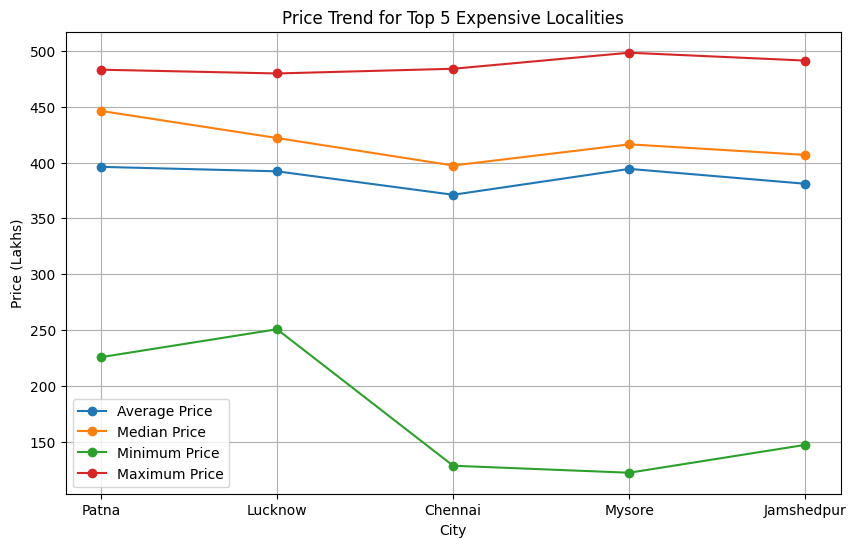

In [615]:
# Visualization
plt.figure(figsize=(10,6))
plt.plot(weighted_top_5_localities['City'], weighted_top_5_localities['avg_price'], marker='o', label='Average Price')
plt.plot(weighted_top_5_localities['City'], weighted_top_5_localities['median_price'], marker='o', label='Median Price')
plt.plot(weighted_top_5_localities['City'], weighted_top_5_localities['min_price'], marker='o', label='Minimum Price')
plt.plot(weighted_top_5_localities['City'], weighted_top_5_localities['max_price'], marker='o', label='Maximum Price')
plt.title("Price Trend for Top 5 Expensive Localities")
plt.xlabel('City')
plt.ylabel('Price (Lakhs)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Feature Relationship & Correlation (11-15)

### 3.1 How are numeric features correlated with each other?

In [616]:
# Getting all numerical features
df_numeric = df.select_dtypes(include='number')
df_numeric.drop('ID', axis=1, inplace=True)
df_numeric

,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,Floor_No,Total_Floors,Age_of_Property,Total_Nearby_Schools,Total_Nearby_Hospitals,Clubhouse,Garden,Gym,Playground,Pool
0,1,4740,0.103,489.76,1990,22,1,35,10,3,1,1,1,1,1
1,3,2364,0.083,195.52,2008,21,20,17,8,1,1,1,1,1,1
2,2,3642,0.050,183.79,1997,19,27,28,9,8,1,0,1,1,1
3,2,2741,0.110,300.29,1991,21,26,34,5,7,1,1,1,1,1
4,4,4823,0.038,182.90,2002,3,2,23,4,9,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,5,1995,0.138,274.75,1995,19,7,30,8,6,1,1,1,1,1
249996,1,2293,0.006,13.40,2013,15,25,12,8,10,0,0,0,1,0
249997,4,2910,0.081,236.94,2003,21,30,22,10,4,0,0,0,1,0
249998,1,1149,0.123,141.66,2007,14,11,18,3,7,0,0,1,1,1


In [617]:
# Creating a correlation matrix
corr_matrix = df_numeric.corr()
corr_matrix

,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,Floor_No,Total_Floors,Age_of_Property,Total_Nearby_Schools,Total_Nearby_Hospitals,Clubhouse,Garden,Gym,Playground,Pool
BHK,1.000000,-0.001033,0.001142,-0.000980,0.000917,0.001263,-0.002862,-0.000917,-0.000762,0.001162,-0.001439,0.000627,-0.004092,-0.000585,-0.001271
Size_in_SqFt,-0.001033,1.000000,-0.614608,-0.002529,0.004135,-0.002775,-0.003451,-0.004135,0.001966,-0.001695,-0.000614,0.000274,-0.005504,0.000011,-0.000937
Price_per_SqFt_in_Lakhs,0.001142,-0.614608,1.000000,0.555784,-0.001329,-0.001900,0.004151,0.001329,-0.000068,-0.000129,0.001062,0.000597,0.003672,-0.000876,0.001346
Price_in_Lakhs,-0.000980,-0.002529,0.555784,1.000000,0.002714,-0.001719,0.001283,-0.002714,0.000155,-0.002769,0.000607,0.000482,0.001945,-0.001817,0.001753
Year_Built,0.000917,0.004135,-0.001329,0.002714,1.000000,-0.000686,0.003452,-1.000000,-0.000591,-0.002719,-0.002966,0.000094,0.001119,0.000075,0.000874
Floor_No,0.001263,-0.002775,-0.001900,-0.001719,-0.000686,1.000000,0.001169,0.000686,-0.000635,0.001428,-0.001946,0.000558,-0.003563,-0.000978,-0.002968
Total_Floors,-0.002862,-0.003451,0.004151,0.001283,0.003452,0.001169,1.000000,-0.003452,-0.003093,-0.005867,-0.001492,-0.002391,0.003716,-0.002522,0.002280
Age_of_Property,-0.000917,-0.004135,0.001329,-0.002714,-1.000000,0.000686,-0.003452,1.000000,0.000591,0.002719,0.002966,-0.000094,-0.001119,-0.000075,-0.000874
Total_Nearby_Schools,-0.000762,0.001966,-0.000068,0.000155,-0.000591,-0.000635,-0.003093,0.000591,1.000000,-0.002246,-0.000163,-0.001738,-0.002360,0.000516,-0.000363
Total_Nearby_Hospitals,0.001162,-0.001695,-0.000129,-0.002769,-0.002719,0.001428,-0.005867,0.002719,-0.002246,1.000000,0.000458,-0.002737,0.001062,0.000654,-0.001294


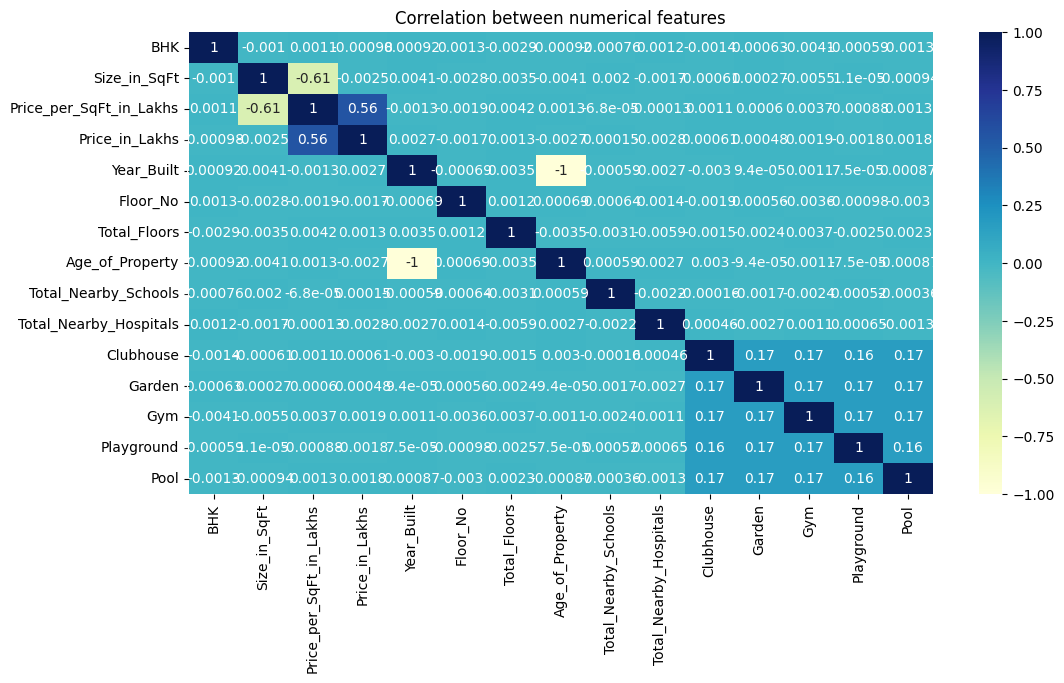

In [618]:
# Visualization
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu')
plt.title("Correlation between numerical features")
plt.show()

### 3.2 Relation between Price per SqFt and Nearby Schools

In [619]:
# Global Correlation between price per sqft and total nearby school
df[['Price_per_SqFt_in_Lakhs', 'Total_Nearby_Schools']].corr()

,Price_per_SqFt_in_Lakhs,Total_Nearby_Schools
Price_per_SqFt_in_Lakhs,1.000000,-0.000068
Total_Nearby_Schools,-0.000068,1.000000


In [620]:
# Correlation between price per sqft and total schools nearby for each city
correlations = (
  df.groupby('City')
  .apply(lambda x: x['Total_Nearby_Schools'].corr(x['Price_per_SqFt_in_Lakhs']))
  .reset_index(name='Correlation_Value')
)
print("Correlation between price per sqft and total schools nearby for each city.")
correlations

Correlation between price per sqft and total schools nearby for each city.


,City,Correlation_Value
0,Ahmedabad,-0.008291
1,Amritsar,0.011104
2,Bangalore,0.004970
3,Bhopal,-0.016573
4,Bhubaneswar,-0.022092
5,Bilaspur,0.007899
6,Chennai,0.015941
7,Coimbatore,-0.032673
8,Cuttack,0.003698
9,Dehradun,-0.021608


In [621]:
# Calculating the number of cities which shows correlation between price per sqft and total schools nearby
city_count = correlations[correlations['Correlation_Value'] >= 0.3][correlations['Correlation_Value'] <= -0.3].shape[0]
print(f"City Count: {city_count}")

City Count: 0


Based on our analysis, we found out that the price per sqft is not affected/related with the total number of schools nearby, based on city.

### 3.3 Relationship between Price per SqFt and nearby hospitals

In [622]:
# Global correlation between price per sqft and hospitals nearby
df[['Price_per_SqFt_in_Lakhs', 'Total_Nearby_Hospitals']].corr()

,Price_per_SqFt_in_Lakhs,Total_Nearby_Hospitals
Price_per_SqFt_in_Lakhs,1.000000,-0.000129
Total_Nearby_Hospitals,-0.000129,1.000000


In [623]:
# Correlation between price per sqft and hospitals nearby based on city
correlation = (
  df.groupby('City')
  .apply(lambda x: x['Total_Nearby_Hospitals'].corr(x['Price_per_SqFt_in_Lakhs']))
  .reset_index(name='Correlation_Value')
)
correlation

,City,Correlation_Value
0,Ahmedabad,-0.010474
1,Amritsar,0.036339
2,Bangalore,-0.009370
3,Bhopal,-0.007645
4,Bhubaneswar,-0.002614
5,Bilaspur,-0.013301
6,Chennai,0.007384
7,Coimbatore,-0.012291
8,Cuttack,0.002875
9,Dehradun,0.007212


In [624]:
# Calculating the number of cities which shows correlation between price per sqft and total hospitals nearby
city_count = correlation[correlation['Correlation_Value'] >= 0.3][correlation['Correlation_Value'] <= -0.3].shape[0]
print(f'City Count: {city_count}')

City Count: 0


Based on our analysis, we found out that the price per sqft is not affected/related with the total number of hospitals nearby, based on city.

### 3.4 Property Price based on Furnishing Status

In [625]:
# Property Price based on Furnishing Status
df_price = df.groupby('Furnished_Status')['Price_in_Lakhs'].agg(['mean', 'median', 'count']).reset_index()
df_price.rename(columns={'mean':'avg_price', 'median':'median_price'})
df_price

,Furnished_Status,mean,median,count
0,Furnished,254.445550,253.555,83218
1,Semi-furnished,254.334836,253.810,83374
2,Unfurnished,254.979752,254.190,83408


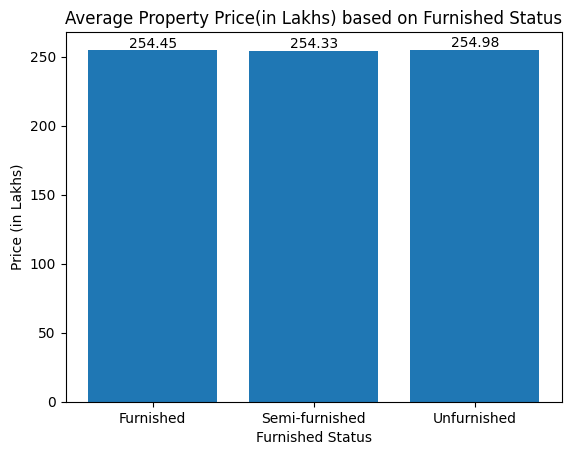

In [626]:
# Visualization
plt.bar(df_price['Furnished_Status'], df_price['mean'])

for index, value in zip(df_price['Furnished_Status'], df_price['mean']):
  plt.text(index, value, f"{value:.2f}", ha='center', va='bottom')

plt.xlabel('Furnished Status')
plt.ylabel('Price (in Lakhs)')
plt.title("Average Property Price(in Lakhs) based on Furnished Status")
plt.show()

In [627]:
# Property price based on Furnishing Status for each city
df_price = df.groupby(['Furnished_Status', 'City'])['Price_in_Lakhs'].agg('mean').reset_index()
df_price

,Furnished_Status,City,Price_in_Lakhs
0,Furnished,Ahmedabad,255.864719
1,Furnished,Amritsar,253.111420
2,Furnished,Bangalore,259.246119
3,Furnished,Bhopal,253.645059
4,Furnished,Bhubaneswar,254.389740
...,...,...,...
121,Unfurnished,Surat,261.620845
122,Unfurnished,Trivandrum,252.104246
123,Unfurnished,Vijayawada,251.677455
124,Unfurnished,Vishakhapatnam,254.586911


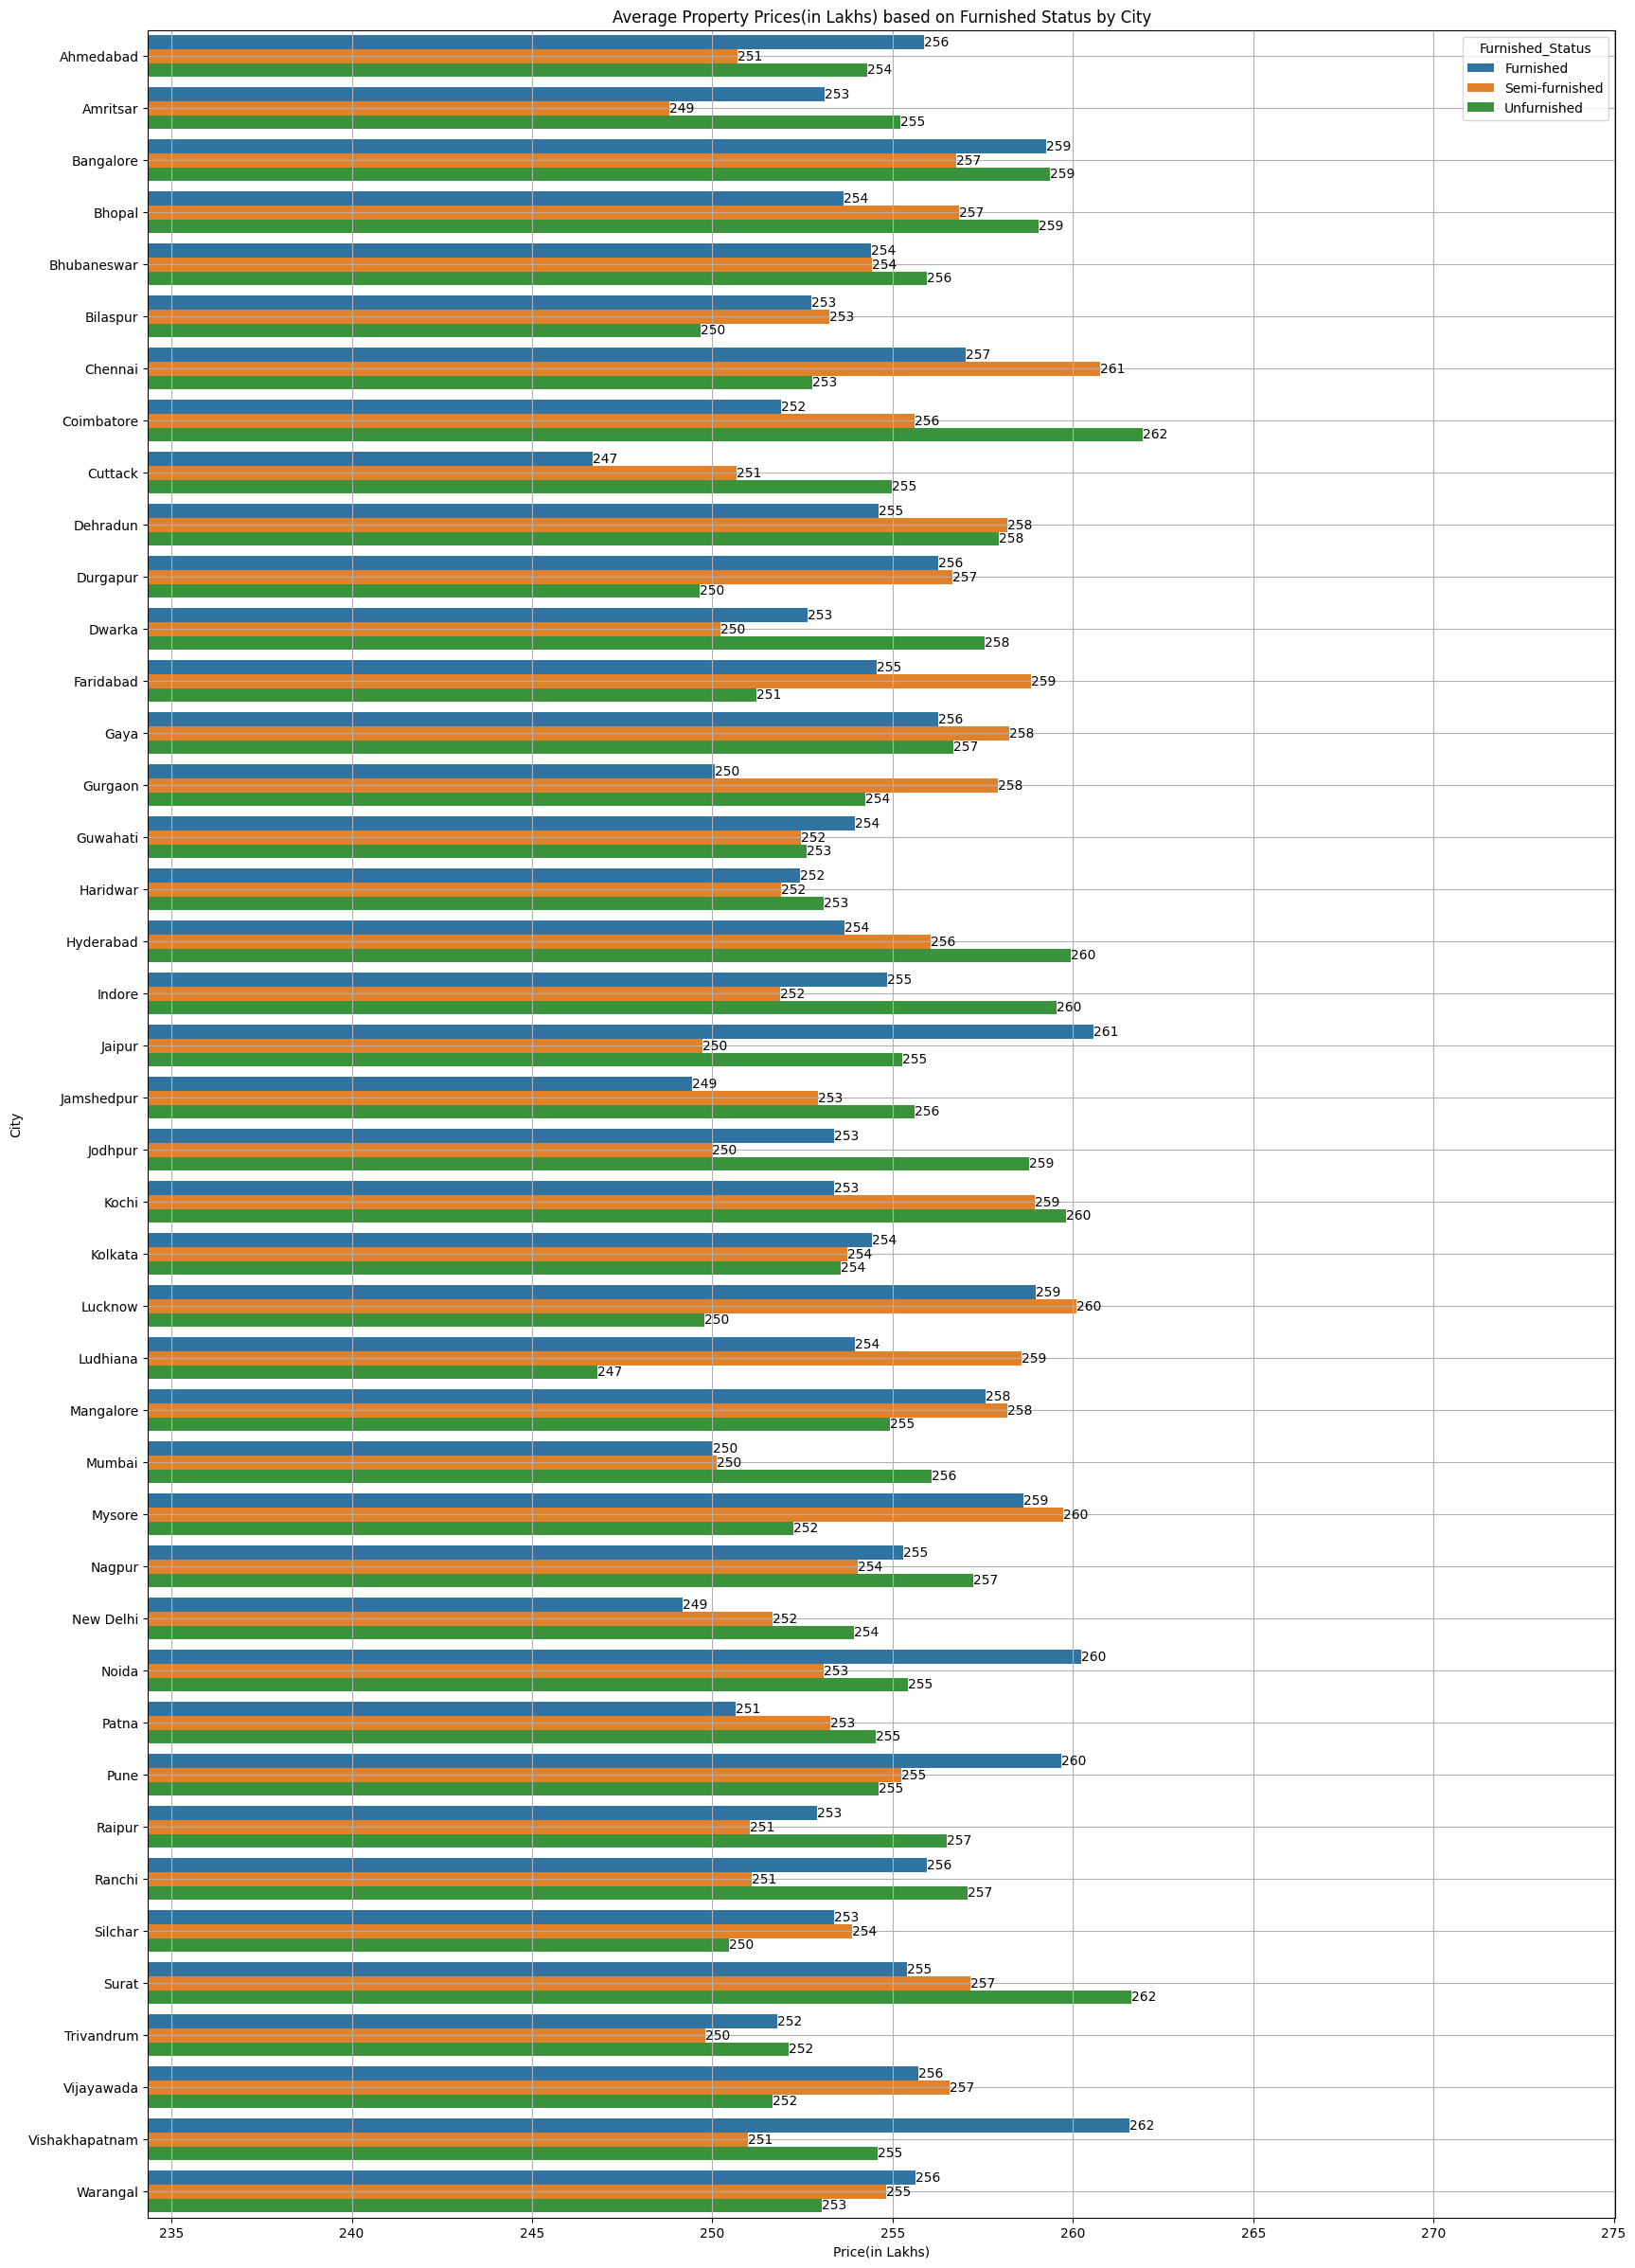

In [628]:
# Visualization
plt.figure(figsize=(20,30))
ax = sns.barplot(
    data=df_price,
    x='Price_in_Lakhs',
    y='City',
    hue='Furnished_Status'
)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='{:.0f}'
    )

plt.xlim(float(df_price['Price_in_Lakhs'].min())*0.95, float(df_price['Price_in_Lakhs'].max())*1.05)
plt.ylabel('City')
plt.xlabel('Price(in Lakhs)')
plt.title('Average Property Prices(in Lakhs) based on Furnished Status by City')
plt.grid(True)
plt.show()

### 3.5 Price per SqFt based on Property Facing Direction

In [629]:
df_facing = df.groupby('Direction_Facing')['Price_per_SqFt_in_Lakhs'].mean().reset_index(name='Avg_Price_per_SqFt')
df_facing

,Direction_Facing,Avg_Price_per_SqFt
0,East,0.130236
1,North,0.130249
2,South,0.130443
3,West,0.131399


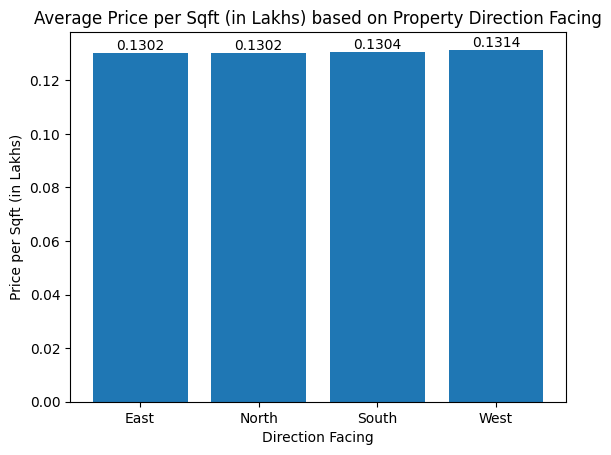

In [630]:
# Visualization
plt.bar(df_facing['Direction_Facing'], df_facing['Avg_Price_per_SqFt'])

for index, value in zip(df_facing['Direction_Facing'], df_facing['Avg_Price_per_SqFt']):
  plt.text(index, value, f"{value:.4f}", ha='center', va='bottom')

plt.title("Average Price per Sqft (in Lakhs) based on Property Direction Facing")
plt.xlabel("Direction Facing")
plt.ylabel("Price per Sqft (in Lakhs)")
plt.show()

In [631]:
# Average price per sqft based on direction facing for each state
df_facing = df.groupby(['State', 'Direction_Facing'])['Price_per_SqFt_in_Lakhs'].mean().reset_index(name='Avg_Price_per_SqFt')
df_facing

,State,Direction_Facing,Avg_Price_per_SqFt
0,Andhra Pradesh,East,0.133710
1,Andhra Pradesh,North,0.130500
2,Andhra Pradesh,South,0.130243
3,Andhra Pradesh,West,0.133606
4,Assam,East,0.127525
...,...,...,...
75,Uttarakhand,West,0.130312
76,West Bengal,East,0.126391
77,West Bengal,North,0.131033
78,West Bengal,South,0.132592


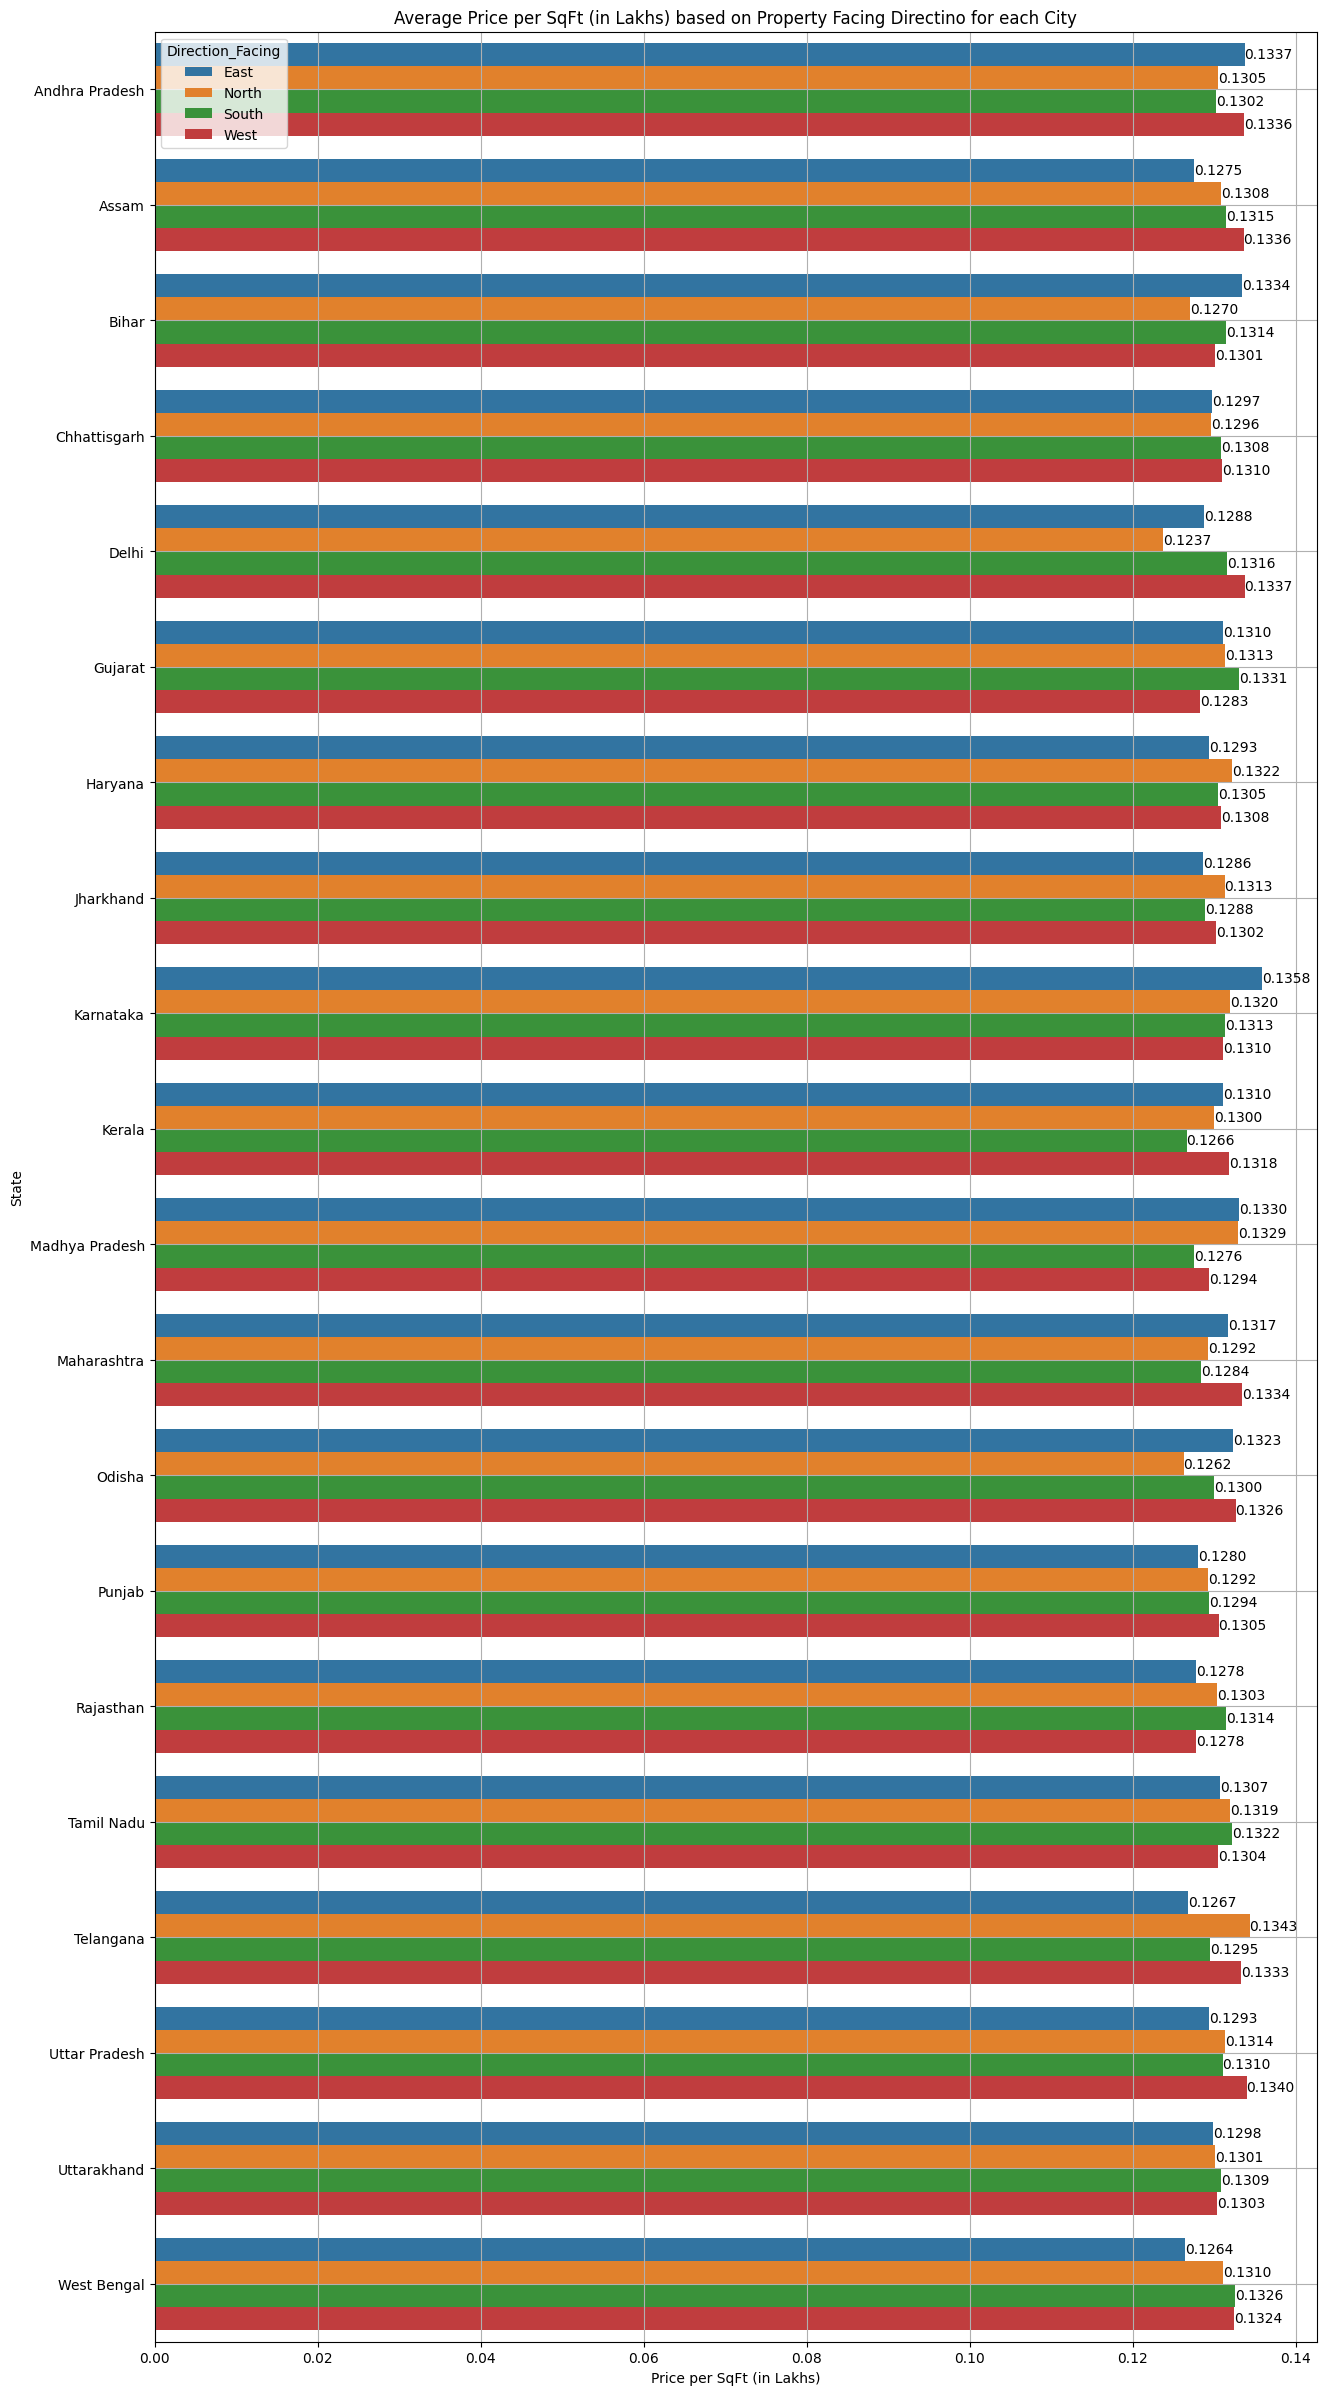

In [632]:
# visualization
plt.figure(figsize=(15,30))
ax = sns.barplot(
  data=df_facing,
  x='Avg_Price_per_SqFt',
  y='State',
  hue='Direction_Facing'
)

for container in ax.containers:
  ax.bar_label(
    container,
    fmt='{:.4f}'
  )

plt.title("Average Price per SqFt (in Lakhs) based on Property Facing Directino for each City")
plt.xlabel("Price per SqFt (in Lakhs)")
plt.grid(True)
plt.show()

## 4. Investment / Amenities / Ownership Analysis (16-20)

### 4.1 Number of properties belonging to each owner type

In [633]:
df_owner_type = df['Owner_Type'].value_counts().reset_index(name='Property_Count')
df_owner_type.sort_values('Property_Count', inplace=True)
df_owner_type

,Owner_Type,Property_Count
2,Builder,83253
1,Owner,83268
0,Broker,83479


### 4.2 Properties available under each availability status

In [634]:
df_availability = df['Availability_Status'].value_counts().reset_index(name='Property_Count')
df_availability['Percentage'] = (df_availability['Property_Count'] / df_availability['Property_Count'].sum()) * 100
df_availability

,Availability_Status,Property_Count,Percentage
0,No,125035,50.014
1,Yes,124965,49.986


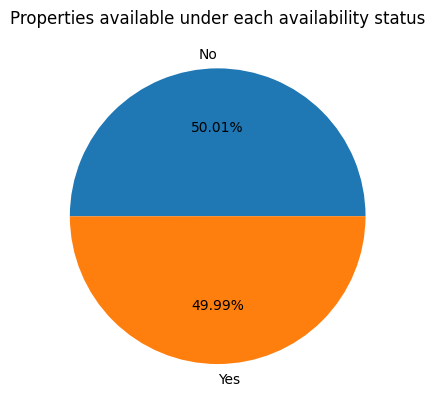

In [635]:
# Visualization
fig, ax = plt.subplots()
ax.pie(df_availability['Percentage'], labels=df_availability["Availability_Status"], autopct='%.2f%%')
plt.title("Properties available under each availability status")
plt.show()

In [636]:
# Property availability in each city
df_availability = (
    df.groupby(['City', 'Availability_Status'])
      .size()
      .reset_index(name='Count')
)

df_availability

,City,Availability_Status,Count
0,Ahmedabad,No,3200
1,Ahmedabad,Yes,3211
2,Amritsar,No,3102
3,Amritsar,Yes,3119
4,Bangalore,No,2084
...,...,...,...
79,Vijayawada,Yes,3113
80,Vishakhapatnam,No,3051
81,Vishakhapatnam,Yes,3067
82,Warangal,No,3120


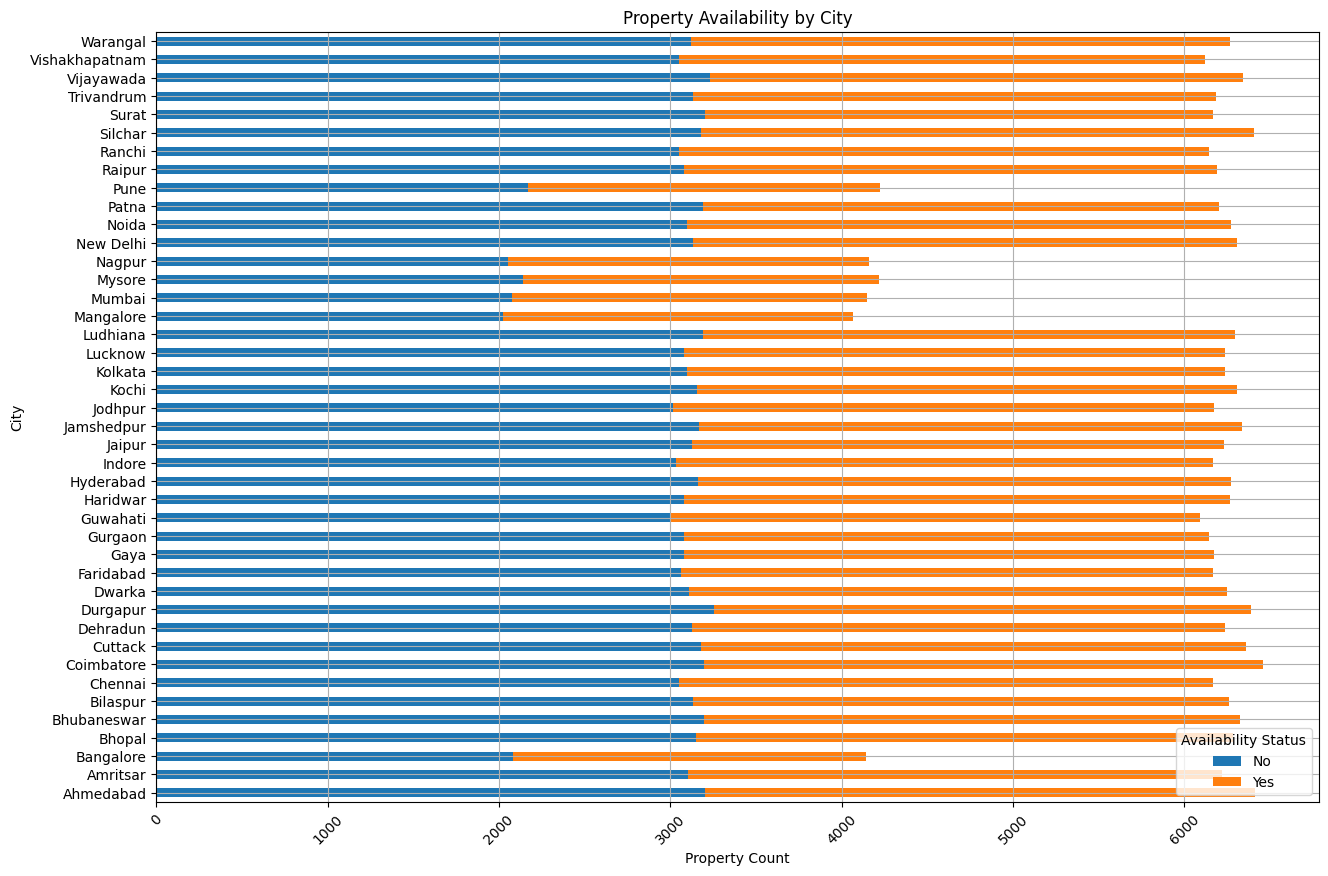

In [637]:
# Visualization
pivot = df_availability.pivot(
    index='City',
    columns='Availability_Status',
    values='Count'
)
pivot.plot(
    kind='barh',
    stacked=True,
    figsize=(15, 10)
)

plt.title('Property Availability by City')
plt.ylabel('City')
plt.xlabel('Property Count')
plt.legend(title='Availability Status')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [638]:
# Percentage of property availability in each city
df_availability = (
  df.groupby('City')['Availability_Status']
  .value_counts(normalize=True)
  .reset_index(name='Percentage')
)
df_availability['Percentage'] = df_availability['Percentage'] * 100
df_availability

,City,Availability_Status,Percentage
0,Ahmedabad,Yes,50.085790
1,Ahmedabad,No,49.914210
2,Amritsar,Yes,50.136634
3,Amritsar,No,49.863366
4,Bangalore,No,50.289575
...,...,...,...
79,Vijayawada,Yes,49.069987
80,Vishakhapatnam,Yes,50.130762
81,Vishakhapatnam,No,49.869238
82,Warangal,Yes,50.207469


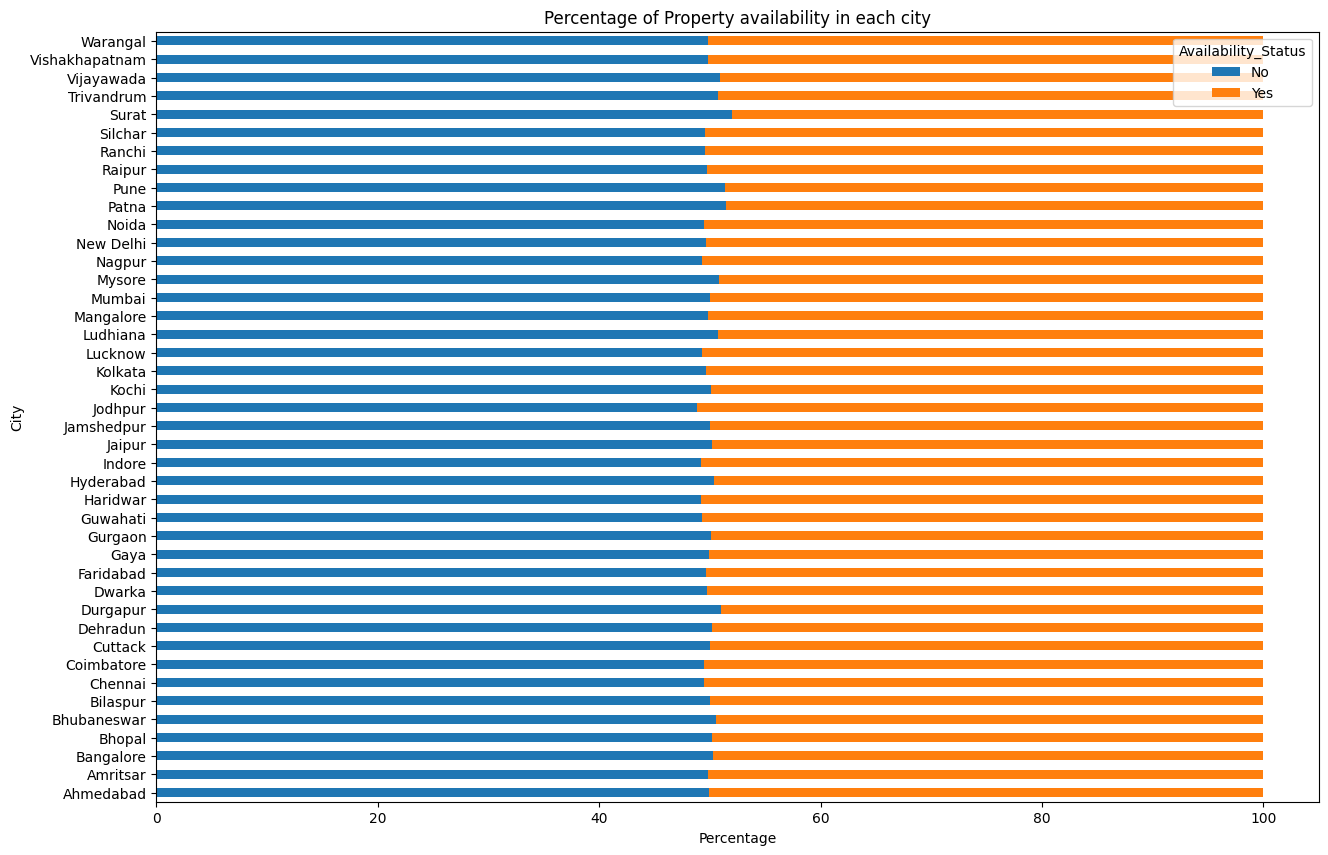

In [639]:
# Visualization
pivot = df_availability.pivot(
    index='City',
    columns='Availability_Status',
    values='Percentage'
)
pivot.plot(
    kind='barh',
    stacked=True,
    figsize=(15, 10)
)
plt.title("Percentage of Property availability in each city")
plt.xlabel('Percentage')
plt.show()

### 4.3 Does parking space affect property price?

In [640]:
# Average property price based on parking space
df_parking = df.groupby('Parking_Space')['Price_in_Lakhs'].mean().reset_index(name='Average_Price')
df_parking

,Parking_Space,Average_Price
0,No,254.429369
1,Yes,254.745492


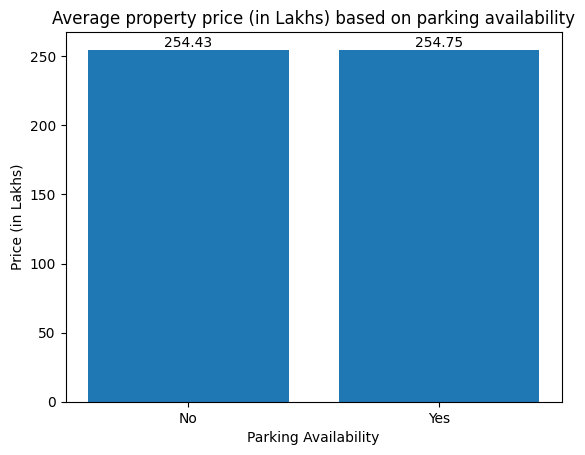

In [641]:
# Visualization
plt.bar(df_parking['Parking_Space'], df_parking['Average_Price'])

for index, value in zip(df_parking['Parking_Space'], df_parking['Average_Price']):
  plt.text(index, value, f"{value:.2f}", ha='center', va='bottom')

plt.title("Average property price (in Lakhs) based on parking availability")
plt.xlabel("Parking Availability")
plt.ylabel("Price (in Lakhs)")
plt.show()

### 4.4 How do amenities affect price per sq ft?

Let's do **Feature Engineering** to create a new feature that will better help us analyse and identify how amenities affect the property price per sqft by:

### Creating weighted amenity scoring system

1. Create individual scores for each amenity.
2. Scale/Normalize the scores.
3. Add all the normalized scores to get the total amenity score with weights assigned.

### 1. Top Priority Amenities - Security, Hospitals, Public Transport Accessibility.

Amenities: 
1. Security - Is already normalized. (Yes/No).
2. Hospitals - Highest score for properties with 5 or more hospitals nearby.
3. Public Transport Availability - Scored ordinally (1 to 3) and normalized.

In [642]:
# Normalizing all the amenities
top_amenities = df[['Security', 'Total_Nearby_Hospitals', 'Public_Transport_Accessibility']].copy()

# Security Score
top_amenities['Security_Score'] = df['Security'].map({'Yes':1,'No':0})

# Hospital Score
top_amenities['Hospital_Score'] = top_amenities['Total_Nearby_Hospitals'].clip(upper=5) / 5

# Public Transport Accessibility Score
transport_map = {
    'Low': 1,
    'Medium':2,
    'High': 3
}
top_amenities['Public_Transport_Accessibility'] = top_amenities['Public_Transport_Accessibility'].map(transport_map)
top_amenities['Transport_Score'] = (top_amenities['Public_Transport_Accessibility'] / 3).round(2)
top_amenities

,Security,Total_Nearby_Hospitals,Public_Transport_Accessibility,Security_Score,Hospital_Score,Transport_Score
0,No,3,3,0,0.6,1.00
1,Yes,1,1,1,0.2,0.33
2,No,8,1,0,1.0,0.33
3,Yes,7,3,1,1.0,1.00
4,Yes,9,1,1,1.0,0.33
...,...,...,...,...,...,...
249995,No,6,1,0,1.0,0.33
249996,No,10,1,0,1.0,0.33
249997,Yes,4,3,1,0.8,1.00
249998,Yes,7,1,1,1.0,0.33


### 2. Medium Priority Amenity - Schools

Considering the type of schools - kindergarden, primary, middle and high school.

Giving full score for property which has 4 and more than 4 schools nearby.

In [643]:
# School Score
medium_amenities = df[['Total_Nearby_Schools']].copy()
medium_amenities['School_Score'] = df['Total_Nearby_Schools'].clip(upper=4) / 4
medium_amenities

,Total_Nearby_Schools,School_Score
0,10,1.00
1,8,1.00
2,9,1.00
3,5,1.00
4,4,1.00
...,...,...
249995,8,1.00
249996,8,1.00
249997,10,1.00
249998,3,0.75


### 3. Low Priority Amenity - Clubhouse, Garden, Gym, Playground, Pool.

Since the amenity data is binary, it is already normalized. So let's add all the value together and normalize the score.

In [644]:
low_amenities = df[['Clubhouse', 'Garden', 'Gym', 'Playground', 'Pool']].copy()
low_amenities['low_priority_score'] = (low_amenities.sum(axis=1)) / 5
low_amenities

,Clubhouse,Garden,Gym,Playground,Pool,low_priority_score
0,1,1,1,1,1,1.0
1,1,1,1,1,1,1.0
2,1,0,1,1,1,0.8
3,1,1,1,1,1,1.0
4,1,1,1,1,1,1.0
...,...,...,...,...,...,...
249995,1,1,1,1,1,1.0
249996,0,0,0,1,0,0.2
249997,0,0,0,1,0,0.2
249998,0,0,1,1,1,0.6


### Assigning weights to the amenities:
* Top Priority : 0.5 / 3 (for each important amenity)
* Medium Priority: 0.3
* Low Priority: 0.2

Adding all the amenity scores together

In [645]:
top_total = 0.6
medium_weight = 0.1
low_weight = 0.2

# Split top across 3 features
top_each = top_total / 3

df['Amenity_Score'] = (
    top_each * top_amenities['Security_Score'] + 
    top_each * top_amenities['Hospital_Score'] + 
    top_each * top_amenities['Transport_Score'] + 
    medium_weight * medium_amenities['School_Score'] + 
    low_weight * low_amenities['low_priority_score']
)
df

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,...,Total_Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Clubhouse,Garden,Gym,Playground,Pool,Amenity_Score
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,0.103,489.76,1990,...,3,High,No,No,1,1,1,1,1,0.620
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,0.083,195.52,2008,...,1,Low,No,Yes,1,1,1,1,1,0.606
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,0.050,183.79,1997,...,8,Low,Yes,No,1,0,1,1,1,0.526
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,0.110,300.29,1991,...,7,High,Yes,Yes,1,1,1,1,1,0.900
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,0.038,182.90,2002,...,9,Low,No,Yes,1,1,1,1,1,0.766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,0.138,274.75,1995,...,6,Low,No,No,1,1,1,1,1,0.566
249996,249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,0.006,13.40,2013,...,10,Low,No,No,0,0,0,1,0,0.406
249997,249998,Telangana,Warangal,Locality_225,Villa,4,2910,0.081,236.94,2003,...,4,High,Yes,Yes,0,0,0,1,0,0.700
249998,249999,Odisha,Cuttack,Locality_138,Villa,1,1149,0.123,141.66,2007,...,7,Low,Yes,Yes,0,0,1,1,1,0.661


In [646]:
# Summary Stats on Amenity Score
df['Amenity_Score'].describe()

count    250000.000000
mean          0.598557
std           0.141844
min           0.171000
25%           0.490000
50%           0.596000
75%           0.704000
max           0.900000
Name: Amenity_Score, dtype: float64

In [647]:
# Correlation between amenity scores and price per sqft
corr_score = df['Amenity_Score'].corr(df['Price_per_SqFt_in_Lakhs'])
print(f"Correlation Value : {corr_score}")

Correlation Value : 5.5081207395689384e-05


In [648]:
# Correlation between amenity scores and price per sqft for each city
print("Correlation between amenity scores and price per sqft for each city")
corr_city = df.groupby('City')['Amenity_Score'].corr(df['Price_per_SqFt_in_Lakhs']).reset_index(name='Correlation_Score')

city_count = corr_city[corr_city['Correlation_Score'] >= 0.3][corr_city['Correlation_Score'] <= -0.3].shape[0]
print(f"Cities with Correlation Count: {city_count}")

corr_city

Correlation between amenity scores and price per sqft for each city
Cities with Correlation Count: 0


,City,Correlation_Score
0,Ahmedabad,-0.008997
1,Amritsar,0.036842
2,Bangalore,-0.017814
3,Bhopal,-0.009670
4,Bhubaneswar,0.003458
5,Bilaspur,-0.011724
6,Chennai,-0.002807
7,Coimbatore,0.008183
8,Cuttack,-0.011037
9,Dehradun,-0.004863


### 4.5.1 Relation between public transport availability and price per sqft

In [649]:
# Average price per sqft based on public transport availability
df_transport = (
  df.groupby('Public_Transport_Accessibility')['Price_per_SqFt_in_Lakhs']
  .agg(['mean','count'])
  .reset_index()
)
df_transport['mean'] = df_transport['mean'] * 100000
df_transport.rename(columns={'mean':'avg_price_per_sqft'}, inplace=True)
df_transport.sort_values('avg_price_per_sqft', ascending=False, inplace=True)

df_transport

,Public_Transport_Accessibility,avg_price_per_sqft,count
1,Low,13085.459916,83287
2,Medium,13062.203643,83008
0,High,13027.282719,83705


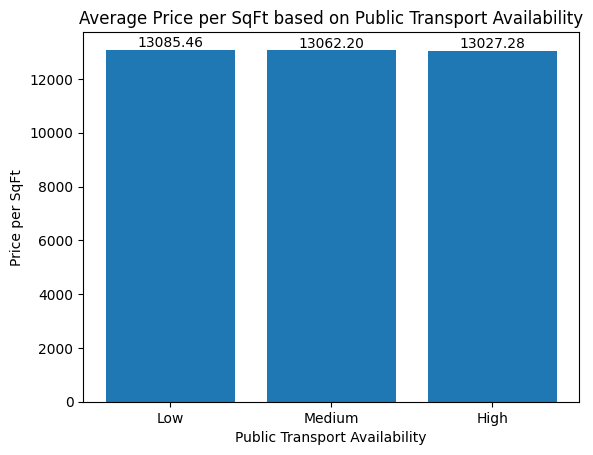

In [650]:
# Visualization
plt.bar(df_transport['Public_Transport_Accessibility'], df_transport['avg_price_per_sqft'])
for index, value in zip(df_transport['Public_Transport_Accessibility'], df_transport['avg_price_per_sqft']):
  plt.text(index, value, f"{value:.2f}", ha='center', va='bottom')

plt.title("Average Price per SqFt based on Public Transport Availability")
plt.xlabel('Public Transport Availability')
plt.ylabel("Price per SqFt")
plt.show()

# Future Property Price Prediction

### Objective: Predict the estimated property price after 5 years.

### Estimating the future price for existing properties based on the features.

Factors that affect the inflation of a property - Location, BHK, Property Type, Amenities, Age

City and Locality

Given below is the growth rate of the cities

In [651]:
city_inflation_rate = {
    # Tier 1 (High growth / metros)
    "Mumbai": 0.09,
    "Bangalore": 0.09,
    "New Delhi": 0.085,
    "Hyderabad": 0.085,
    "Chennai": 0.08,
    "Kolkata": 0.075,
    "Pune": 0.08,
    "Ahmedabad": 0.075,
    "Gurgaon": 0.085,
    "Noida": 0.085,
    "Faridabad": 0.075,
    "Dwarka": 0.08,

    # Tier 2 (Strong growth cities)
    "Jaipur": 0.07,
    "Lucknow": 0.07,
    "Indore": 0.07,
    "Bhopal": 0.065,
    "Nagpur": 0.065,
    "Coimbatore": 0.07,
    "Kochi": 0.07,
    "Trivandrum": 0.07,
    "Surat": 0.075,
    "Vijayawada": 0.07,
    "Vishakhapatnam": 0.07,
    "Mysore": 0.065,
    "Mangalore": 0.065,
    "Guwahati": 0.065,
    "Bhubaneswar": 0.07,
    "Cuttack": 0.065,
    "Raipur": 0.065,
    "Ranchi": 0.065,
    "Jamshedpur": 0.065,
    "Dehradun": 0.065,
    "Haridwar": 0.06,
    "Warangal": 0.06,

    # Tier 3 (Moderate / emerging)
    "Ludhiana": 0.06,
    "Amritsar": 0.06,
    "Jodhpur": 0.06,
    "Durgapur": 0.055,
    "Bilaspur": 0.055,
    "Gaya": 0.055,
    "Patna": 0.065,
    "Silchar": 0.05
}

with open('Datasets/city_inflation.json','w') as f:
    json.dump(city_inflation_rate, f, indent=4)

In [652]:
future_price = df.copy()

City-Based Inflation

In [653]:
with open('Datasets/city_inflation.json', 'r') as file:
  city_inflation_rate = json.load(file)

future_price['City_Inflation_Rate'] = future_price['City'].map(city_inflation_rate)

Locality-Based Inflation

In [654]:
# 1. Computing Average price per sqft per locality
locality_price = (
  future_price.groupby(['City', 'Locality'])['Price_per_SqFt_in_Lakhs']
  .mean()
  .reset_index()
  .rename(columns={'Price_per_SqFt_in_Lakhs':'Avg_Price_per_SqFt'})
)

# 2. Categorizing localities (Cheap/Moderate/Expensive)
q1 = locality_price['Avg_Price_per_SqFt'].quantile(0.33)
q2 = locality_price['Avg_Price_per_SqFt'].quantile(0.66)

def classify_locality(x):
    if x <= q1:
        return 'Cheap'
    elif x <= q2:
        return 'Moderate'
    else:
        return 'Expensive'

locality_price['locality_type'] = locality_price['Avg_Price_per_SqFt'].apply(classify_locality)

# 3. Assigning Inflation Rates
locality_inflation_map = {
  'Cheap': 0.08,
  'Moderate': 0.06,
  'Expensive': 0.04
}

locality_price['locality_inflation_rate'] = locality_price['locality_type'].map(locality_inflation_map)

Combining City and Locality Growth Rate together

In [655]:
future_price = future_price.merge(
  locality_price[['City', 'Locality', 'locality_type', 'locality_inflation_rate']],
  on=['City', 'Locality'],
  how='left'
) 

future_price['Base_Inflation_Rate'] = future_price['City_Inflation_Rate'] + future_price['locality_inflation_rate']
future_price['Base_Inflation_Rate'].describe()

count    250000.000000
mean          0.128856
std           0.018682
min           0.090000
25%           0.115000
50%           0.130000
75%           0.145000
max           0.170000
Name: Base_Inflation_Rate, dtype: float64

Creating Property Type Weight

In [656]:
property_type_weight = {
    'Apartment': 1.00,
    'Independent House': 1.08,
    'Villa': 1.05  
}

future_price['Property_Type_Weight'] = (
    future_price['Property_Type']
    .map(property_type_weight)
)
future_price['Property_Type_Weight'].describe()

count    250000.000000
mean          1.043405
std           0.032954
min           1.000000
25%           1.000000
50%           1.050000
75%           1.080000
max           1.080000
Name: Property_Type_Weight, dtype: float64

Creating BHK Inflation Weights

In [657]:
bhk_inflation_weight = {
  1: 1.1,
  2: 1.15,
  3: 1.00,
  4: 0.95,
  5: 0.90
}

future_price['BHK_weight'] = future_price['BHK'].map(bhk_inflation_weight)
future_price['BHK_weight'].describe()

count    250000.000000
mean          1.019956
std           0.092716
min           0.900000
25%           0.950000
50%           1.000000
75%           1.100000
max           1.150000
Name: BHK_weight, dtype: float64

Amenity Impact on Inflation

In [658]:
amenity_mean = df['Amenity_Score'].mean()

future_price['Amenity_Weight'] = (
  1 + ((future_price['Amenity_Score'] - amenity_mean) / amenity_mean).clip(lower=0) * 0.2
)

future_price['Amenity_Weight'].describe()

count    250000.000000
mean          1.019554
std           0.026830
min           1.000000
25%           1.000000
50%           1.000000
75%           1.035233
max           1.100723
Name: Amenity_Weight, dtype: float64

Property Depreciation based on Age

In [659]:
age_price = future_price.groupby('Age_of_Property')['Price_per_SqFt_in_Lakhs'].mean()
age_price = age_price.rolling(5, min_periods=1).mean()
age_weight = age_price / age_price.max()
age_weight_map = age_weight.to_dict()
future_price['Age_Weight'] = (
  future_price['Age_of_Property']
  .map(age_weight_map)
  .fillna(1.0)
)

future_price['Age_Weight'].describe()

count    250000.000000
mean          0.990065
std           0.004867
min           0.982082
25%           0.986074
50%           0.989757
75%           0.994720
max           1.000000
Name: Age_Weight, dtype: float64

Adjusted Total Inflation Rate

In [660]:
future_price['Adjusted_Inflation_Rate'] = (
  future_price['Base_Inflation_Rate'] 
  * future_price['BHK_weight'] 
  * future_price['Property_Type_Weight']
  * future_price['Amenity_Weight']
  * future_price['Age_Weight']
)
future_price['Adjusted_Inflation_Rate'].describe()

count    250000.000000
mean          0.138434
std           0.024515
min           0.079549
25%           0.120092
50%           0.136800
75%           0.154839
max           0.231384
Name: Adjusted_Inflation_Rate, dtype: float64

Estimating Property Price after 5 yrs

In [661]:
future_price['Future_Price_5Y'] = future_price['Price_in_Lakhs'] * ((1 + future_price['Adjusted_Inflation_Rate'] ) ** 5)
future_price[['Future_Price_5Y']]

,Future_Price_5Y
0,912.302247
1,393.467805
2,314.467048
3,641.611647
4,313.898344
...,...
249995,506.712272
249996,24.837995
249997,384.061709
249998,252.224745


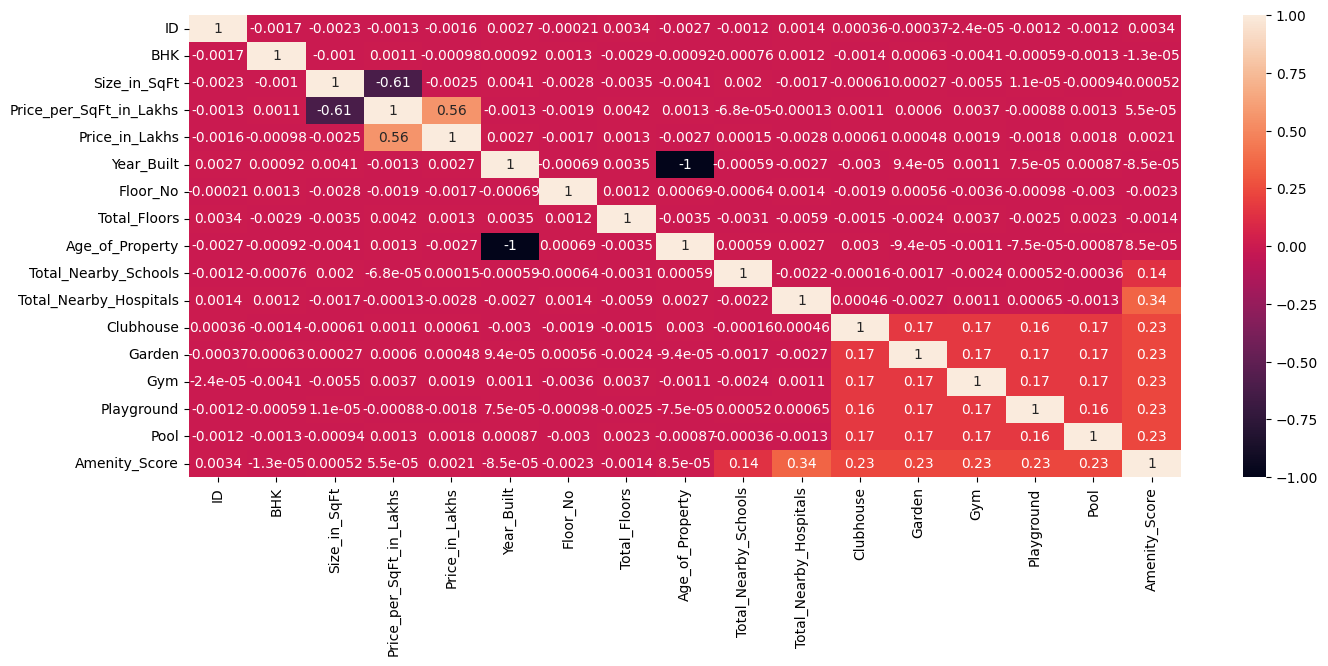

In [662]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16,6))
sns.heatmap(
  data=corr,
  annot=True
)
plt.show()

Adding the Future Price to main dataframe

In [663]:
df['Future_Price_5Y'] = future_price['Future_Price_5Y']

Saving the dataframe in a seperate csv file for regression

In [664]:
final_data = df.copy()
final_data.to_csv('Datasets/Future_Price.csv', index=False)

# Property Investment Checker

## Objective: Classify whether investing the property is good or not.

In [665]:
"""df['ROI'] = (df['Future_Price_5Y'] - df['Price_in_Lakhs']) / df['Price_in_Lakhs']

q1 = df['ROI'].quantile(0.33)
q2 = df['ROI'].quantile(0.66)

def classify_roi(x):
    if x >= q2:
        return "Good"
    elif x >= q1:
        return "Average"
    else:
        return "Bad"

df['Investment_Label'] = df['ROI'].apply(classify_roi)"""

'df[\'ROI\'] = (df[\'Future_Price_5Y\'] - df[\'Price_in_Lakhs\']) / df[\'Price_in_Lakhs\']\n\nq1 = df[\'ROI\'].quantile(0.33)\nq2 = df[\'ROI\'].quantile(0.66)\n\ndef classify_roi(x):\n    if x >= q2:\n        return "Good"\n    elif x >= q1:\n        return "Average"\n    else:\n        return "Bad"\n\ndf[\'Investment_Label\'] = df[\'ROI\'].apply(classify_roi)'

In [666]:
with open('Datasets/city_inflation.json', 'r') as file:
  city_inflation = json.load(file)

def inflation_score(city):
    """0/1/2 based on city's annual inflation rate."""
    rate = city_inflation.get(city, 0.065)   # fallback: median
    if rate >= 0.085:
        return 2
    elif rate >= 0.07:
        return 1
    else:
        return 0

def roi_score(current_price, future_price):
    """0/1/2 based on 5-year projected ROI %."""
    roi_pct = (future_price - current_price) / current_price * 100
    if roi_pct >= 25:
        return 2
    elif roi_pct >= 10:
        return 1
    else:
        return 0

def age_penalty(age):
    """Penalty subtracted from ROI score for older properties."""
    if age <= 5:
        return 0
    elif age <= 15:
        return -1
    elif age <= 25:
        return -1      # -1 compounded; adj. ROI clamped at 0
    else:
        return -2      # very old property, strong drag

def amenity_score_band(amenity_score):
    """0/1/2 from normalized amenity score."""
    if amenity_score >= 0.70:
        return 2
    elif amenity_score >= 0.40:
        return 1
    else:
        return 0

# ── 3. Row-level label function ────────────────────────────────────────────────

WEIGHTS = {
    "inflation": 0.35,   # city macro signal
    "roi":       0.40,   # financial return (dominant factor)
    "amenity":   0.25,   # livability / demand driver
}

def label_property(row):
    s_inflation = inflation_score(row["City"])
    s_roi       = roi_score(row["Price_in_Lakhs"], row["Future_Price_5Y"])
    s_roi_adj   = max(0, s_roi + age_penalty(row["Age_of_Property"]))
    s_amenity   = amenity_score_band(row["Amenity_Score"])

    weighted = (
        WEIGHTS["inflation"] * s_inflation +
        WEIGHTS["roi"]       * s_roi_adj   +
        WEIGHTS["amenity"]   * s_amenity
    )

    if weighted >= 0.65:
        return "Yes"
    else:
        return "No"

# ── 4. Apply ───────────────────────────────────────────────────────────────────

df["Invest"] = df.apply(label_property, axis=1)

# ── 5. Sanity check ────────────────────────────────────────────────────────────
print(df["Invest"].value_counts(normalize=True).mul(100).round(1))

Invest
Yes    75.4
No     24.6
Name: proportion, dtype: float64


In [667]:
df

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,...,Parking_Space,Security,Clubhouse,Garden,Gym,Playground,Pool,Amenity_Score,Future_Price_5Y,Invest
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,0.103,489.76,1990,...,No,No,1,1,1,1,1,0.620,912.302247,No
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,0.083,195.52,2008,...,No,Yes,1,1,1,1,1,0.606,393.467805,Yes
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,0.050,183.79,1997,...,Yes,No,1,0,1,1,1,0.526,314.467048,No
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,0.110,300.29,1991,...,Yes,Yes,1,1,1,1,1,0.900,641.611647,No
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,0.038,182.90,2002,...,No,Yes,1,1,1,1,1,0.766,313.898344,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,0.138,274.75,1995,...,No,No,1,1,1,1,1,0.566,506.712272,No
249996,249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,0.006,13.40,2013,...,No,No,0,0,0,1,0,0.406,24.837995,Yes
249997,249998,Telangana,Warangal,Locality_225,Villa,4,2910,0.081,236.94,2003,...,Yes,Yes,0,0,0,1,0,0.700,384.061709,Yes
249998,249999,Odisha,Cuttack,Locality_138,Villa,1,1149,0.123,141.66,2007,...,Yes,Yes,0,0,1,1,1,0.661,252.224745,Yes


Saving the dataframe in a seperate csv file for classification

In [668]:
investment_df = df.copy()
investment_df.to_csv('Datasets/Property_Investment.csv', index=False)